In [1]:
%matplotlib inline
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as plt
import scipy.integrate as integrate
import scipy.linalg as linalg
import IPython
import emcee
import os
from multiprocessing.pool import ThreadPool
from matplotlib.ticker import MaxNLocator
from getdist import plots, MCSamples, loadMCSamples, types
from scipy.special import gamma
from scipy.integrate import quad

os.environ["OMP_NUM_THREADS"] = "1"

plt.rcParams.update({
    "text.usetex": True,                # Usa o motor LaTeX para escrever tudo
    "font.family": "serif",             # Usa fonte serifada
    "font.serif": ["Palatino"],         # Especifica a fonte padrão do LaTeX
    "axes.labelsize": 16,               # Tamanho dos rótulos (H0, Wm)
    "font.size": 14,                    # Tamanho geral
    "legend.fontsize": 14,              # Tamanho da legenda
    "xtick.labelsize": 12,              # Tamanho dos números no eixo X
    "ytick.labelsize": 12,              # Tamanho dos números no eixo Y
})

np.random.seed(321)

# Carregando os dados

In [2]:
zhzi, hzi, shzi = np.genfromtxt('data/Hz33Clocks.txt', comments='#', usecols=(0,1,2), unpack=True)
zmod, imf, slib, sps, spsooo = np.genfromtxt('data/data_MM20.dat', comments='#', usecols=(0,1,2,3,4), unpack=True)

In [3]:
priorArray = np.array([[50., 100.], [0.0, 3.0], [-3.0, 3.0], [0.1, 2]])
nstepHz = 5000
ndata = len(zhzi)

### stat + imf + slib + sps

In [9]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
slib_intp = np.interp(zhzi, zmod, slib)/100
sps_intp = np.interp(zhzi, zmod, sps)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_slib = np.zeros((ndata, ndata), dtype='float64')
cov_mat_sps = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = hzi[i] * slib_intp[i] * hzi[j] * slib_intp[j]
        cov_mat_sps[i,j] = hzi[i] * sps_intp[i] * hzi[j] * sps_intp[j]

cov_mat = cov_mat_imf + cov_mat_slib + cov_mat_sps + cov_mat_diag
inv_cov3 = linalg.inv(cov_mat)

# Funções de análise

In [21]:
#Function to identify which model will be used
def free_par(theta, freef, flat):
    if freef == True:
        if flat == False:
            h0, wm, wl, f = theta
            return [h0, wm, wl, f]
        elif flat == True:
            h0, wm, f = theta
            return [h0, wm, 1-wm, f]
        else:
            print("Invalid flatness...")
            return None
    elif freef == False:
        if flat == False:
            h0, wm, wl = theta
            return [h0, wm, wl, 1]
        elif flat == True:
            h0, wm = theta
            return [h0, wm, 1-wm, 1]
        else:
            print("Invalid flatness...")
            return None
    else:
        print("Invalid correction parameter...")
        return None

#Calculate chi2 for the model
def chi2Hz(par):
    E2 = par[1]*(1+zhzi)**3+(1-par[1]-par[2])*(1+zhzi)**2+par[2]

    if np.any(E2<0):
        return np.inf

    Hzm = par[0]*np.sqrt(E2)
    dhz = hzi-Hzm
    inv_covCorr = inv_cov/par[3]**2

    return np.dot(np.dot(dhz.T, inv_covCorr), dhz)

#Check if parameters are in prior interval
def lnpriorHz(par):
    for i in range(len(par)):
        if not priorArray[i][0] < par[i] < priorArray[i][1]:
            return -np.inf
    return 0.0

#Calculate the likelihood
def lnlikeHz(par):
    chi2 = chi2Hz(par)
    return -0.5*chi2 - ndata*np.log(par[3])

def lnlikeHzA(par):
    chi2 = chi2Hz(par)
    return -0.5*chi2 - ndata*np.log(par[3])


def lnprobHz(theta, freef, flat):
    par = free_par(theta, freef, flat)
    
    lp = lnpriorHz(par)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlikeHz(par)

#Minimize chi2
def find_bestfit(lnlike, par_ml, parnames, freef, flat):
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda par_ml, freef, flat: -2*lnlike(par_ml, freef, flat)
    result = op.minimize(chi2, par_ml, args=(freef, flat))
    if not result['success']:
        result = op.minimize(chi2, par_ml, args=(freef, flat), method='Nelder-Mead', options={'maxiter': 10000})
    par_ml = result['x']
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    t2 = time.time()
    print('Total time: {0:5.3f} seg'.format(t2-t1))
    return result

#Run MC
def run_emcee(par_ml, nwalkers, lnprob, freef, flat, ainput, nsteps):
    ndim = len(par_ml)
    pos = [par_ml +1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    
    with ThreadPool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=[freef, flat], a=ainput, pool=pool)
        sampler.run_mcmc(pos, nsteps, progress=True)
    
    accept = sampler.acceptance_fraction
    print('Acceptance fraction:',accept)
    print('Minimum acceptance:',np.amin(accept))
    print('Maximum acceptance:',np.amax(accept))
    
    return sampler

#Remove burn in
def tira_burnin(sampler, burnin, ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples


def burninthin(sampler, tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

#MC results
def MC_result(samples, par_ml, parnames):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865525393149998], axis=0)[0]
    par_valp = np.percentile(samples, [84.13447460685], axis=0)[0]
    par_valm2 = np.percentile(samples, [2.275013194800002], axis=0)[0]
    par_valp2 = np.percentile(samples, [97.7249868052], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    par_sigm2 = par_mean - par_valm2
    par_sigp2 = par_valp2 - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} +{3:5.5f} -{4:5.5f} -{5:5.5f} (median: {6:5.5f}, ml: {7:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigp2[i],par_sigm[i],par_sigm2[i],par_median[i],par_ml[i]))

#Insert a derived paramater
def insertDerived(sample, parnames, parlabel, num, gsample, derived, derivedName, derivedLabel):
    n = np.zeros(num)
    
    if derivedName not in parnames:
        newSample = np.c_[sample, derived]
        parnames.append(derivedName)
        gsample.addDerived(derived, name=derivedName, label=derivedLabel)
        
        return newSample, gsample, parnames, n

    elif derivedName in parnames:
        print('Parâmetro dependente já adicionado.')

        return sample, gsample, parnames, n

#Distribution funcion for chi2
def chiDist(chi, n):
    return (n**(n/2)*((chi)**((n-2)/2))*np.exp(-(n/2)*chi))/(2**(n/2)*gamma(n/2))

#Calculate cdf for chiDist
def chiCDF(x, n):
    res = np.zeros_like(x)
    for i, val in enumerate(x):
        y, err = quad(chiDist, 0, val, args=(n))
        res[i]=y
    return res

#Plot chi2 cdf
def plotChiDist(chimin, par, name=0):
    n = ndata - par
    chi = np.linspace(0, 2.5, 500)
    chiv = np.full((500), chimin/n)
    hv = chiDist(chi, n)
    cdf = chiCDF(chi, n)
    y = np.linspace(0, 1.8, 500)
    
    plt.plot(chi, hv, label=r"$h _{\nu}$")
    plt.plot(chiv, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(np.round(chimin/n, 3)))
    plt.plot(chi, cdf, '--', label="cdf")
    
    plt.xticks(np.arange(0.0, 2.51, 0.5))
    plt.yticks(np.arange(0.0, 1.76, 0.25))
    plt.axis((0, 2.5, 0, 1.75))
    plt.grid(linestyle='-.', linewidth='0.5')
    plt.minorticks_on()
    
    plt.ylabel(r'$h_{\nu}$')
    plt.xlabel(r'$\chi _{\nu} ^{2}$')
    plt.legend(loc='best')
   
    if not name == 0:
        plt.savefig('fig/'+name+'.pdf')
    
    plt.show()

def MCResult(sampler):
    if hasattr(sampler, 'products'):
        gdsamples = sampler.products()['sample'][0].to_getdist()
    else:
        gdsamples = sampler
    
    stats = gdsamples.getMargeStats()

    resultados = {'params': {}}

    for parametro in stats.names:
        par_stats = stats.parWithName(parametro.name)

        media = par_stats.mean

        # Erros de 1s
        inf_1s = par_stats.limits[0].lower
        sup_1s = par_stats.limits[0].upper

        # Erros de 2s
        inf_2s = par_stats.limits[1].lower
        sup_2s = par_stats.limits[1].upper

        print(f'{parametro.name} = {media:.4f} + {(sup_1s - media):.4f} + {(sup_2s - media):.4f} -{(media - inf_1s):.4f} -{(media - inf_2s):.4f}')

# Matriz de covariância: stat + imf + slib + spsooo
### OLCDM sem correção

In [5]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
slib_intp = np.interp(zhzi, zmod, slib)/100
spsooo_intp = np.interp(zhzi, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_slib = np.zeros((ndata, ndata), dtype='float64')
cov_mat_spsooo = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = hzi[i] * slib_intp[i] * hzi[j] * slib_intp[j]
        cov_mat_spsooo[i,j] = hzi[i] * spsooo_intp[i] * hzi[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_slib + cov_mat_spsooo + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

In [6]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False)
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  63.919914204009274
wm  =  0.3833000763764333
wl  =  0.7587115253684147
chi2min = 13.792909513381943
Total time: 0.017 seg


In [7]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 168.05it/s]

Acceptance fraction: [0.6314 0.6332 0.6078 0.6258 0.622  0.625  0.6214 0.6412 0.6236 0.6222
 0.6178 0.6186 0.6198 0.629  0.6286 0.6296 0.6242 0.6098 0.6204 0.6254
 0.6252 0.625  0.6106 0.6232 0.6362 0.6318 0.6222 0.6186 0.619  0.615
 0.6324 0.6224 0.6336 0.6458 0.6278 0.6218 0.6182 0.616  0.6112 0.635
 0.6174 0.6228 0.6238 0.608  0.6252 0.6372 0.6174 0.6316 0.642  0.6238
 0.6182 0.6194 0.6348 0.6246 0.6206 0.6312 0.6356 0.6182 0.6142 0.6226
 0.6082 0.628  0.6404 0.6274 0.6352 0.6126 0.6238 0.6142 0.6382 0.6316
 0.6364 0.6142 0.6258 0.626  0.6376 0.625  0.6176 0.6172 0.6126 0.6302
 0.6292 0.6374 0.6192 0.6268 0.6252 0.623  0.612  0.6076 0.6248 0.6216
 0.635  0.6204 0.6224 0.6286 0.6246 0.617  0.6324 0.62   0.6344 0.618 ]
Minimum acceptance: 0.6076
Maximum acceptance: 0.6458


In [8]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[41.55547436 39.09684139 39.34069611]
120.3210907227679
Convergiu! :)


In [9]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [10]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 62.43834 +7.16098 +15.32791 -7.43578 -11.50239 (median: 61.93169, ml: 63.91991)
wm = 0.39932 +0.22083 +0.45377 -0.22891 -0.36827 (median: 0.38516, ml: 0.38330)
wl = 0.70899 +0.41837 +0.79859 -0.43291 -0.82908 (median: 0.72415, ml: 0.75871)


In [11]:
gsamplesHzC = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


In [13]:
MCResult(gsamplesHzC)

H0 = 62.4383 + 5.4114 + 13.4985 -8.6967 -12.1506
wm = 0.3993 + 0.1924 + 0.3700 -0.2518 -0.3993
wl = 0.7090 + 0.4350 + 0.7813 -0.4092 -0.8126


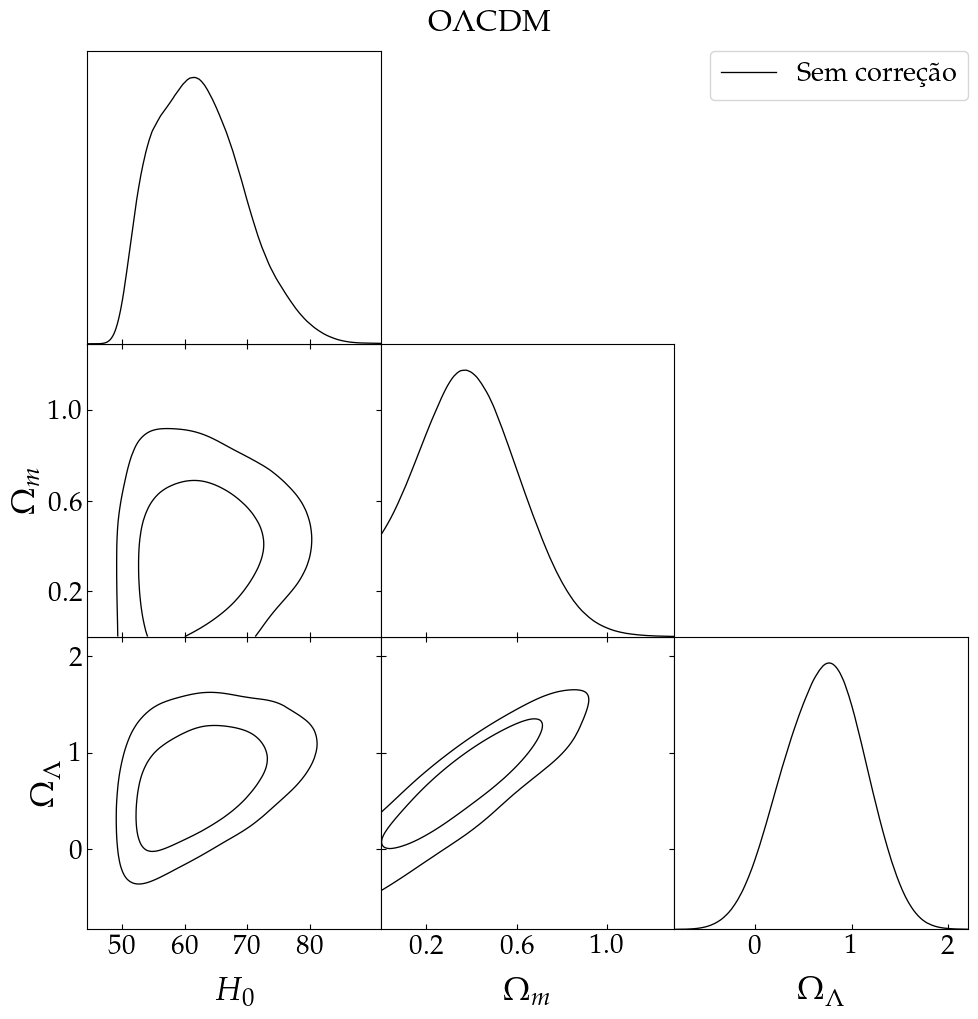

In [16]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)
plt.show()
#g.export('fig/OLCDM-no-f.pdf')

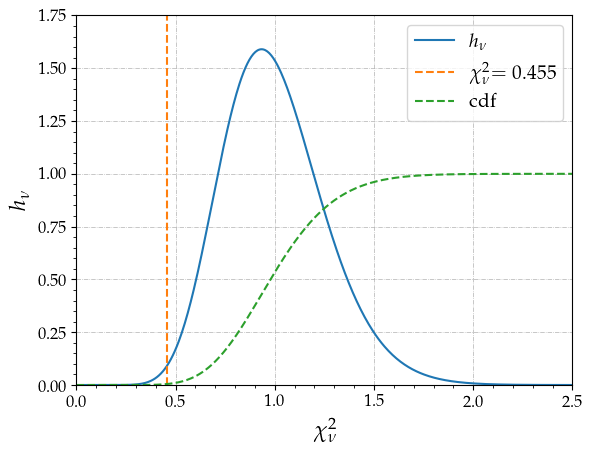

Probabilidade =  0.45761568379974826
Chiv =  0.45495804641406784


In [61]:
chi2mC = chi2Hz(free_par([62.4383, 0.3993, 0.7090], freef=False, flat=False))
chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata-len(par_HzC)), args=(ndata-len(par_HzC)))
plotChiDist(chi2mC, len(par_HzC))
print('Probabilidade = ', chivCperc*100)
print('Chiv = ', chi2mC/(ndata-len(par_HzC)))

### OLCDM com correção

In [23]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False)
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  63.91998162768951
wm  =  0.3832975482066293
wl  =  0.7587081517271704
f  =  0.6465038026144025
chi2min = 4.21235414469394
Total time: 0.040 seg


In [24]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 170.21it/s]

Acceptance fraction: [0.584  0.578  0.572  0.5844 0.5772 0.5852 0.5796 0.5952 0.5886 0.5878
 0.574  0.5826 0.5812 0.5854 0.595  0.5906 0.584  0.5774 0.5818 0.5886
 0.5726 0.5798 0.585  0.5832 0.5716 0.5992 0.5852 0.5832 0.5794 0.5892
 0.5782 0.5774 0.585  0.5874 0.5908 0.5808 0.579  0.5842 0.5694 0.5732
 0.5842 0.5808 0.5706 0.5884 0.5858 0.5962 0.5756 0.5888 0.5972 0.5852
 0.59   0.5806 0.579  0.567  0.5748 0.5764 0.5928 0.5616 0.569  0.5862
 0.5638 0.5748 0.5894 0.5922 0.5906 0.5872 0.589  0.5722 0.5708 0.573
 0.586  0.5718 0.5734 0.5824 0.5856 0.5932 0.5806 0.5778 0.5792 0.574
 0.5808 0.5842 0.5874 0.5864 0.5816 0.5894 0.5802 0.5796 0.5768 0.5834
 0.5836 0.5746 0.5888 0.5926 0.5836 0.5798 0.5824 0.5754 0.577  0.5716]
Minimum acceptance: 0.5616
Maximum acceptance: 0.5992


In [25]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[45.33759839 46.02119516 46.57287329 44.9488329 ]
107.3586327576893
Convergiu! :)


In [26]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [27]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 62.37498 +5.61763 +11.61832 -5.79461 -10.58713 (median: 62.21778, ml: 63.91998)
wm = 0.37453 +0.16740 +0.33931 -0.17291 -0.31972 (median: 0.37176, ml: 0.38330)
wl = 0.68319 +0.33154 +0.60667 -0.33783 -0.70001 (median: 0.70055, ml: 0.75871)
f = 0.70597 +0.09371 +0.21403 -0.09167 -0.15786 (median: 0.69536, ml: 0.64650)


In [29]:
gsamplesHzCF = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


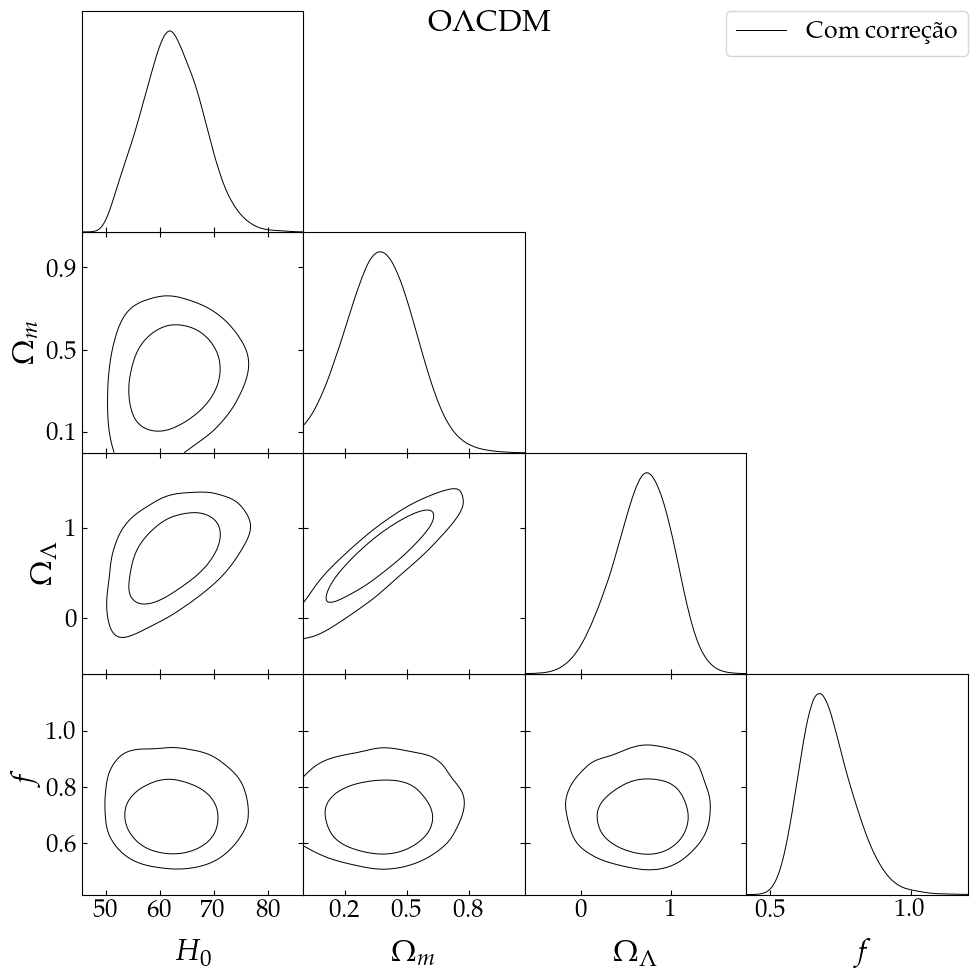

In [30]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
#g.export('fig/OLCDM-f.pdf')
plt.show()

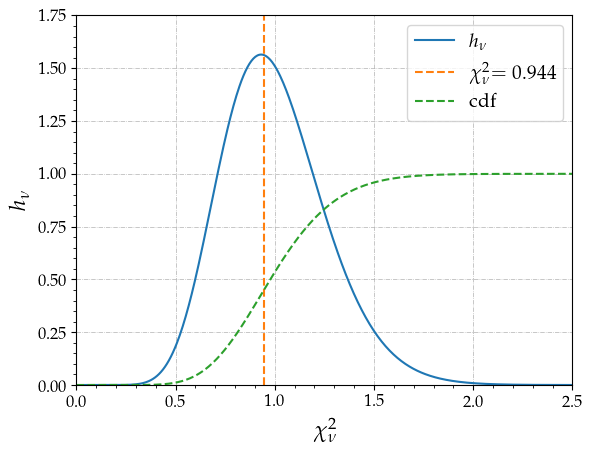

Probabilidade =  44.792158848453866
Chiv =  0.9435830025978452


In [62]:
chi2CF=chi2Hz(free_par([62.37498, 0.37453, 0.68319, 0.70597], freef=True, flat=False))
plotChiDist(chi2CF, len(par_HzCF))
chivCFperc, errF = quad(chiDist, 0, chi2CF/(ndata-len(par_HzCF)), args=(ndata-len(par_HzCF)))
print('Probabilidade = ', chivCFperc*100)
print('Chiv = ', chi2CF/(ndata-len(par_HzCF)))

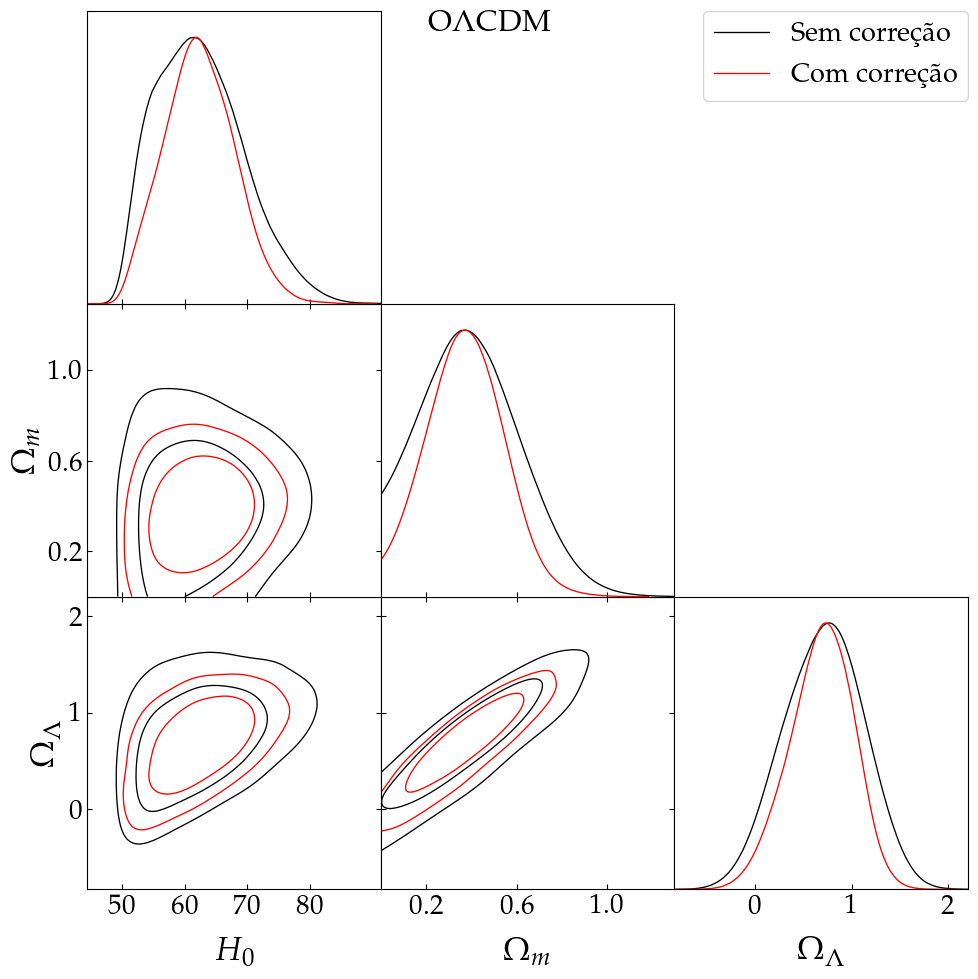

In [32]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC, gsamplesHzCF], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
plt.show()

### FLCDM sem correção

In [34]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True)
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  63.2190212830185
wm  =  0.33688633703147297
chi2min = 13.83213381297701
Total time: 0.007 seg


In [35]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:32<00:00, 152.43it/s]

Acceptance fraction: [0.7198 0.718  0.7058 0.7086 0.7104 0.7066 0.7064 0.7192 0.7102 0.7188
 0.6998 0.7098 0.7082 0.7146 0.716  0.7208 0.727  0.7008 0.7046 0.7146
 0.709  0.7188 0.7092 0.7176 0.7134 0.714  0.715  0.7184 0.713  0.717
 0.7156 0.7208 0.715  0.7092 0.7092 0.7102 0.7162 0.7148 0.7112 0.706
 0.6896 0.7122 0.7168 0.7178 0.7124 0.7152 0.7046 0.7296 0.732  0.7158
 0.7074 0.7144 0.7078 0.7154 0.706  0.7268 0.7188 0.7028 0.7064 0.7148
 0.7    0.7106 0.7248 0.7152 0.7142 0.721  0.7188 0.6938 0.7076 0.7108
 0.7214 0.7194 0.7056 0.7054 0.7192 0.7144 0.7178 0.6974 0.7104 0.7282
 0.7182 0.717  0.7166 0.714  0.7094 0.7102 0.7022 0.7108 0.7114 0.7104
 0.7084 0.7098 0.7096 0.71   0.7176 0.703  0.7234 0.7102 0.7104 0.706 ]
Minimum acceptance: 0.6896
Maximum acceptance: 0.732


In [36]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[32.87115493 32.35582839]
152.10904548347415
Convergiu! :)


In [37]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(30800, 2)


In [38]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 62.58236 +6.94550 +14.19691 -7.03303 -11.43990 (median: 62.20768, ml: 69.19300)
wm = 0.35435 +0.07604 +0.17310 -0.07559 -0.13022 (median: 0.34653, ml: 0.24809)


In [39]:
gsamplesHzF = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


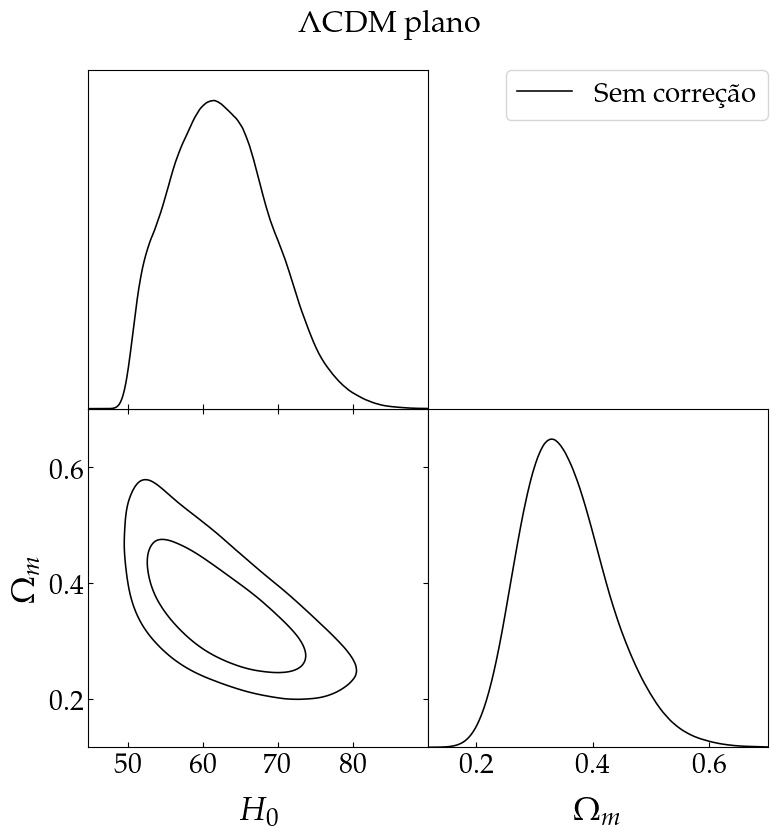

In [40]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
plt.show()
#g.export('fig/FLCDM-no-f.pdf')

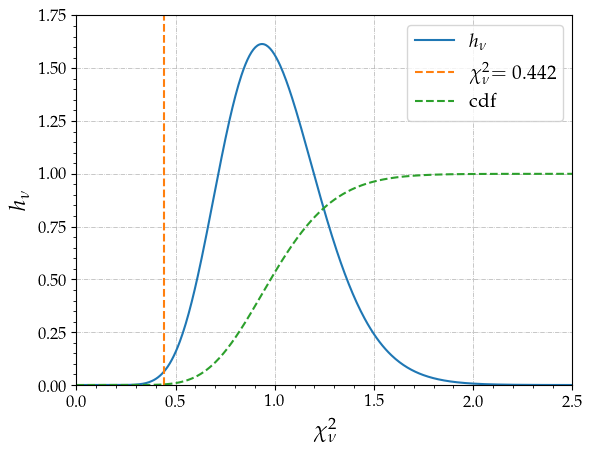

Probabilidade =  0.3091480753392133
Chiv =  0.4424323713550232


In [63]:
chi2F=chi2Hz(free_par([62.58236, 0.35435], freef=False, flat=True))
plotChiDist(chi2F, len(par_HzF))
chivFperc, errF = quad(chiDist, 0, chi2F/(ndata-len(par_HzF)), args=(ndata-len(par_HzF)))
print('Probabilidade = ', chivFperc*100)
print('Chiv = ', chi2F/(ndata-len(par_HzF)))

### FLCDM com correção

In [83]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True)
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  58.840385936119105
wm  =  0.38085840329888004
f  =  0.6414321378868799
chi2min = 3.692575589853874
Total time: 0.009 seg


In [84]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 2.0, 20000)

100%|████████████████████████████████████| 20000/20000 [02:02<00:00, 162.62it/s]

Acceptance fraction: [0.63095 0.6258  0.62315 0.6193  0.62205 0.62625 0.62055 0.62355 0.62325
 0.623   0.61965 0.6269  0.6195  0.62105 0.6265  0.6286  0.624   0.62205
 0.62245 0.6293  0.63005 0.62895 0.618   0.61445 0.62225 0.62385 0.6227
 0.6284  0.6218  0.62685 0.6181  0.62575 0.6237  0.62865 0.6165  0.61965
 0.6294  0.63015 0.62315 0.6205  0.61735 0.6212  0.63485 0.6267  0.62875
 0.6286  0.62865 0.62045 0.6251  0.62865 0.62055 0.62625 0.62    0.6186
 0.6245  0.62695 0.6246  0.6227  0.6208  0.6238  0.62725 0.62405 0.6206
 0.613   0.62565 0.62505 0.62945 0.6216  0.62315 0.62655 0.6131  0.62065
 0.6213  0.61625 0.62595 0.62615 0.6239  0.6211  0.6318  0.6254  0.6231
 0.6185  0.6208  0.6253  0.62695 0.6255  0.61835 0.6225  0.62245 0.6229
 0.6227  0.6216  0.6232  0.6237  0.62145 0.63375 0.62665 0.61655 0.6265
 0.62205]
Minimum acceptance: 0.613
Maximum acceptance: 0.63485


In [85]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[46.18591969 46.00130363 42.9651052 ]
108.25810188885369
Convergiu! :)


In [86]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(94800, 3)


In [87]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 59.59193 +6.25070 +13.99830 -6.35902 -9.06504 (median: 58.81831, ml: 58.84039)
wm = 0.38416 +0.07429 +0.15130 -0.07359 -0.13345 (median: 0.38070, ml: 0.38086)
f = 0.68577 +0.08769 +0.21159 -0.08775 -0.15221 (median: 0.67605, ml: 0.64143)


In [97]:
gsamplesHzFf = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


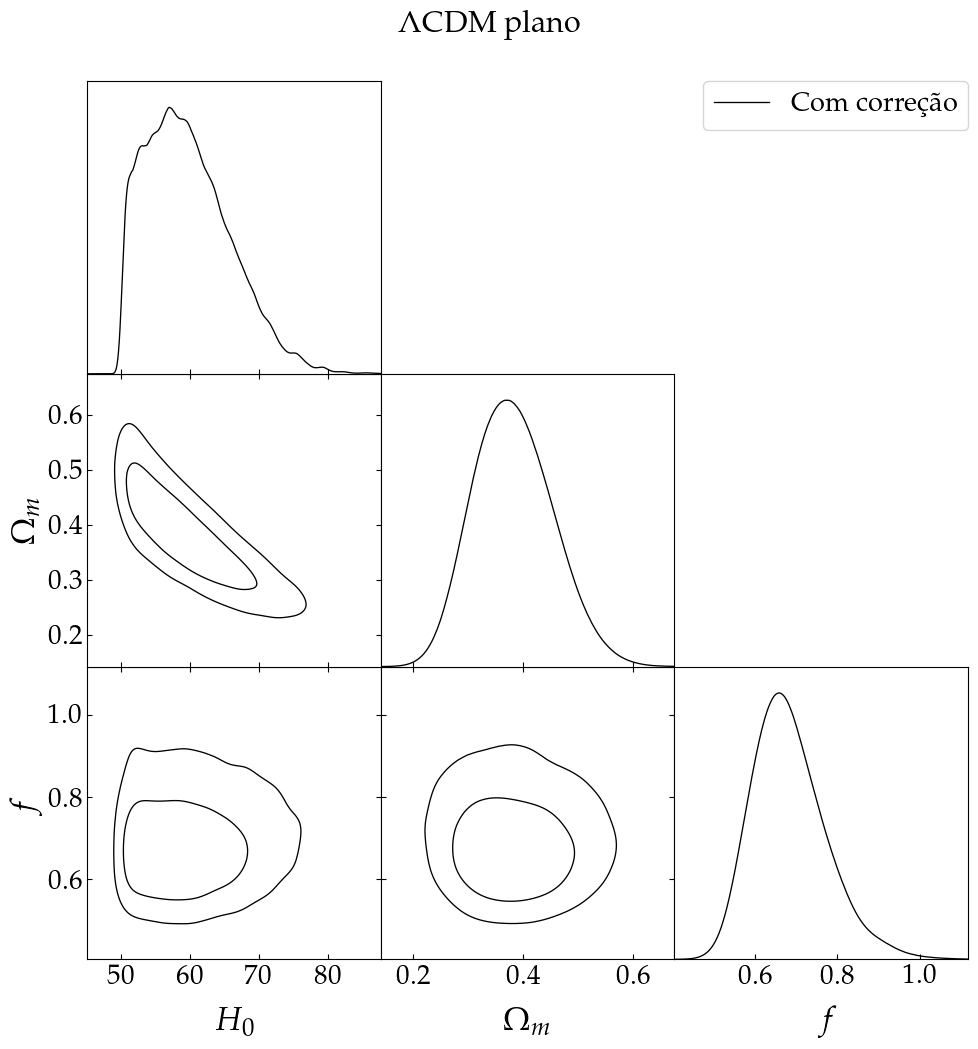

In [98]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
plt.show()
#g.export('fig/FLCDM-f.pdf')

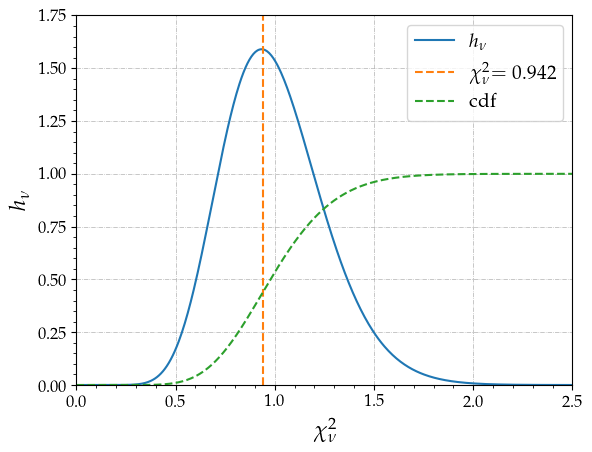

Probabilidade =  44.321314523836634
Chiv =  0.9419207168885606


In [64]:
chi2Ff=chi2Hz(free_par([62.62895, 0.34816, 0.69614], freef=True, flat=True))
plotChiDist(chi2Ff, len(par_HzFf))
chivFfperc, errF = quad(chiDist, 0, chi2Ff/(ndata-len(par_HzFf)), args=(ndata-len(par_HzFf)))
print('Probabilidade = ', chivFfperc*100)
print('Chiv = ', chi2Ff/(ndata-len(par_HzFf)))

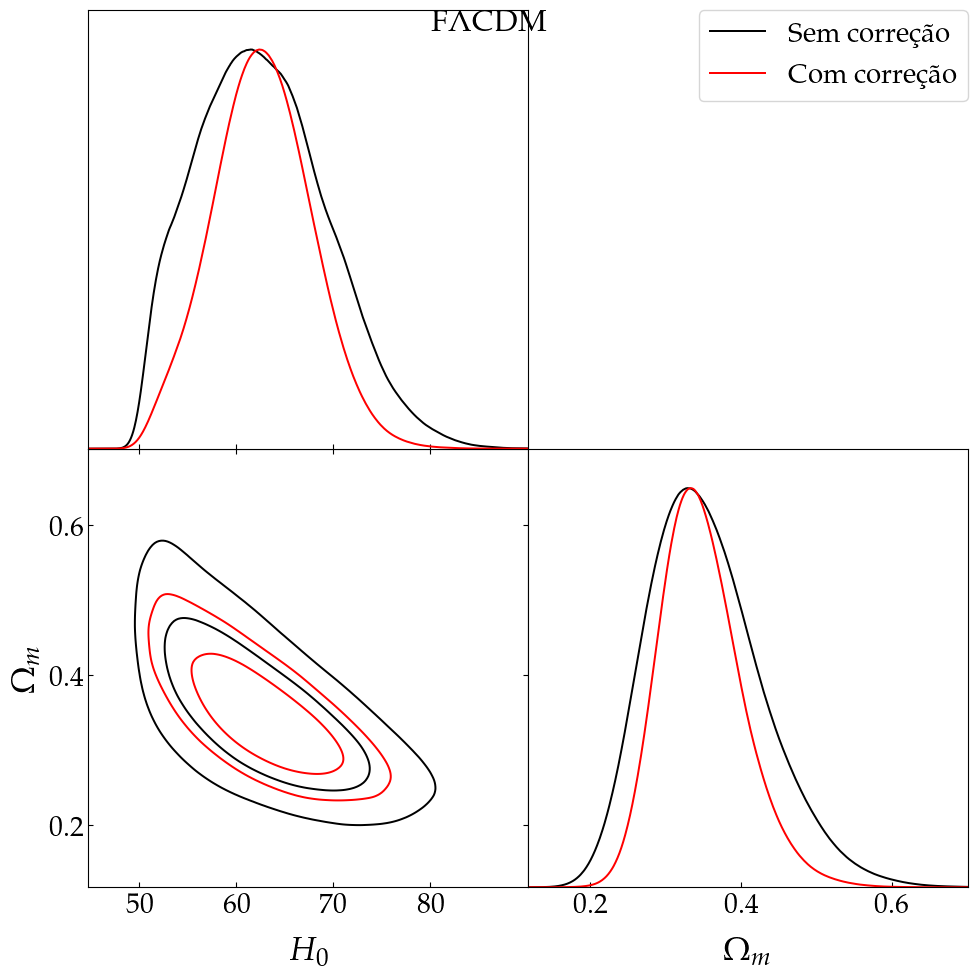

In [51]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF, gsamplesHzFf], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM", fontsize=22)
plt.show()

# Matriz de covariância: stat + imf + slib + sps
### OLCDM sem correção

In [162]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
slib_intp = np.interp(zhzi, zmod, slib)/100
sps_intp = np.interp(zhzi, zmod, sps)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_slib = np.zeros((ndata, ndata), dtype='float64')
cov_mat_sps = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = hzi[i] * slib_intp[i] * hzi[j] * slib_intp[j]
        cov_mat_sps[i,j] = hzi[i] * sps_intp[i] * hzi[j] * sps_intp[j]

cov_mat = cov_mat_imf + cov_mat_slib + cov_mat_sps + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

In [53]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False)
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  59.45320816508737
wm  =  0.4685340170125521
wl  =  0.7848449747021752
chi2min = 13.478981037894476
Total time: 0.009 seg


In [54]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:27<00:00, 180.36it/s]

Acceptance fraction: [0.612  0.5998 0.581  0.6144 0.604  0.5966 0.5966 0.604  0.6036 0.6154
 0.5896 0.5898 0.5928 0.6108 0.6022 0.6184 0.623  0.6144 0.6078 0.616
 0.611  0.61   0.596  0.5988 0.6026 0.6158 0.6068 0.5994 0.6012 0.6056
 0.6036 0.5924 0.6064 0.6162 0.6152 0.5972 0.6066 0.609  0.5886 0.6044
 0.6006 0.5974 0.6074 0.6164 0.6078 0.6252 0.602  0.6124 0.617  0.6196
 0.6002 0.592  0.6198 0.5978 0.5988 0.6104 0.6084 0.6038 0.6054 0.6042
 0.592  0.599  0.6114 0.6018 0.6036 0.6114 0.5964 0.5958 0.6052 0.6114
 0.5956 0.5976 0.6034 0.606  0.6196 0.6054 0.5996 0.5852 0.6212 0.6054
 0.6004 0.616  0.609  0.5978 0.601  0.6062 0.598  0.5972 0.6082 0.5988
 0.6094 0.6042 0.6016 0.6046 0.6068 0.599  0.61   0.6014 0.6126 0.6096]
Minimum acceptance: 0.581
Maximum acceptance: 0.6252


In [55]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[47.85838435 41.1937706  43.57185855]
104.47490168034335
Convergiu! :)


In [56]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [57]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 60.28950 +7.66553 +18.18833 -7.58196 -9.89595 (median: 58.83390, ml: 59.45321)
wm = 0.49578 +0.27469 +0.60238 -0.28434 -0.44963 (median: 0.47237, ml: 0.46853)
wl = 0.79417 +0.45303 +0.87193 -0.46061 -0.89170 (median: 0.80036, ml: 0.78484)


In [58]:
gsamplesHzC1 = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


In [59]:
MCResult(gsamplesHzC1)

H0 = 60.2895 + 3.2511 + 14.6804 -9.8956 -10.6102
wm = 0.4958 + 0.2225 + 0.4821 -0.3285 -0.4958
wl = 0.7942 + 0.4514 + 0.8493 -0.4565 -0.8765


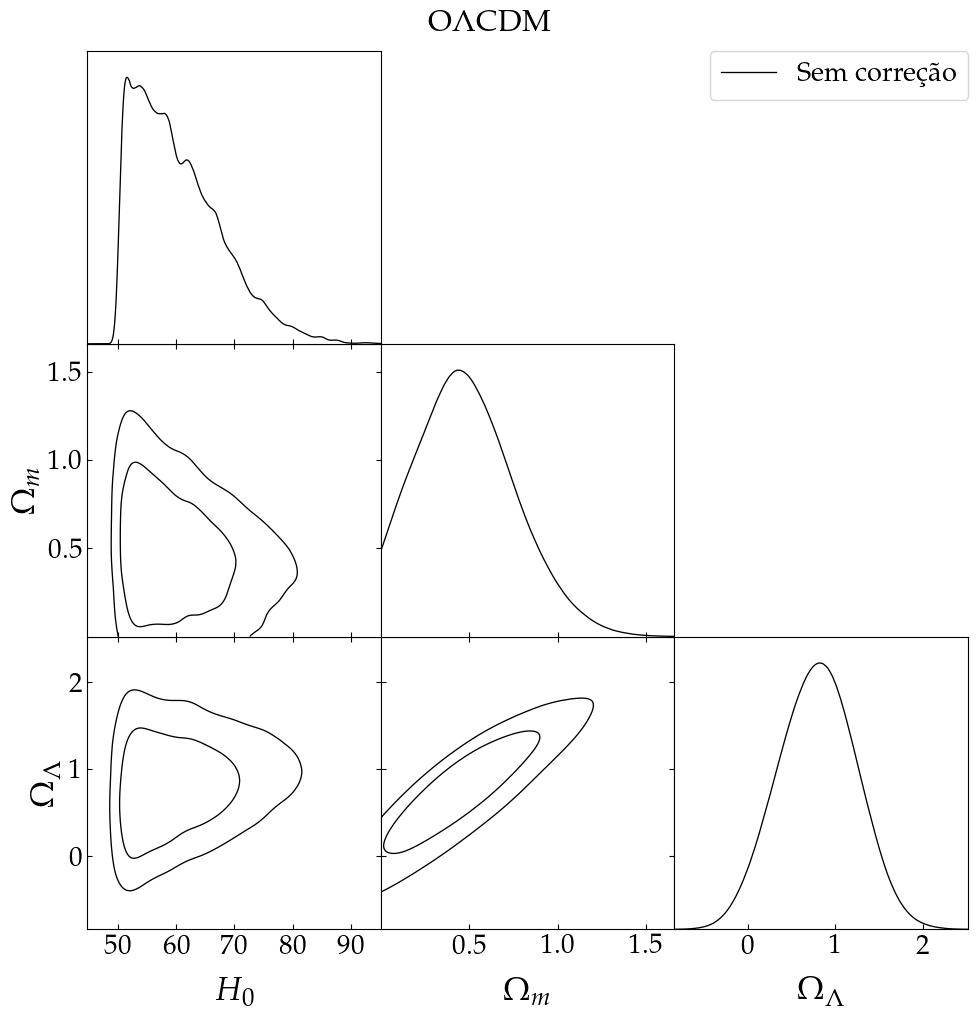

In [60]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC1], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)
plt.show()
#g.export('fig/OLCDM-no-f.pdf')

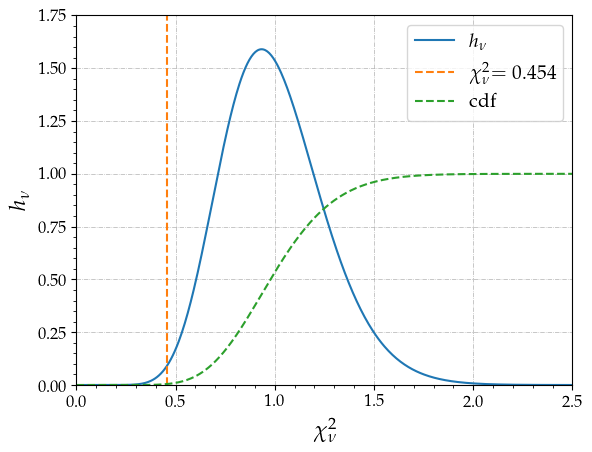

Probabilidade =  0.451925275890787
Chiv =  0.45431450768837


In [65]:
chi2mC = chi2Hz(free_par([60.2895, 0.4958, 0.7942], freef=False, flat=False))
chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata-len(par_HzC)), args=(ndata-len(par_HzC)))
plotChiDist(chi2mC, len(par_HzC))
print('Probabilidade = ', chivCperc*100)
print('Chiv = ', chi2mC/(ndata-len(par_HzC)))

### OLCDM com correção

In [66]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False)
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  59.45322569270124
wm  =  0.4685337561067378
wl  =  0.7848450195369112
f  =  0.6391040418701225
chi2min = 3.452590366485424
Total time: 0.011 seg


/home/nirk/miniforge3/envs/cosmo_env/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


In [67]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 171.15it/s]

Acceptance fraction: [0.584  0.57   0.5536 0.5624 0.5654 0.5574 0.575  0.553  0.5568 0.5744
 0.5544 0.5692 0.5688 0.565  0.5632 0.5894 0.5786 0.5554 0.5666 0.5782
 0.5662 0.5662 0.5648 0.5582 0.5806 0.5686 0.5564 0.5682 0.5642 0.5702
 0.5628 0.5572 0.5662 0.586  0.5728 0.549  0.5682 0.568  0.555  0.5606
 0.5572 0.5658 0.553  0.5608 0.5534 0.5764 0.5486 0.5762 0.5692 0.5532
 0.5638 0.5706 0.5588 0.5678 0.5432 0.5722 0.5696 0.5552 0.5628 0.5662
 0.5612 0.5618 0.5784 0.5676 0.563  0.5584 0.5456 0.5632 0.5576 0.5756
 0.569  0.5662 0.5652 0.5632 0.5736 0.5676 0.5782 0.5574 0.573  0.58
 0.5626 0.5768 0.5746 0.5668 0.5664 0.5704 0.5574 0.5698 0.5606 0.551
 0.569  0.5542 0.5572 0.5688 0.5652 0.5684 0.5698 0.5664 0.5662 0.5638]
Minimum acceptance: 0.5432
Maximum acceptance: 0.5894


In [68]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[54.07724742 47.37230973 49.16089139 49.06350644]
92.46032737667338
Convergiu! :)


In [69]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [70]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 59.08927 +6.27967 +13.82985 -6.24086 -8.60254 (median: 58.21751, ml: 59.45323)
wm = 0.47946 +0.20681 +0.45131 -0.21406 -0.39169 (median: 0.47238, ml: 0.46853)
wl = 0.75942 +0.34774 +0.67715 -0.35903 -0.72180 (median: 0.77189, ml: 0.78485)
f = 0.69360 +0.09152 +0.21976 -0.09059 -0.15724 (median: 0.68233, ml: 0.63910)


In [71]:
gsamplesHzCF1 = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


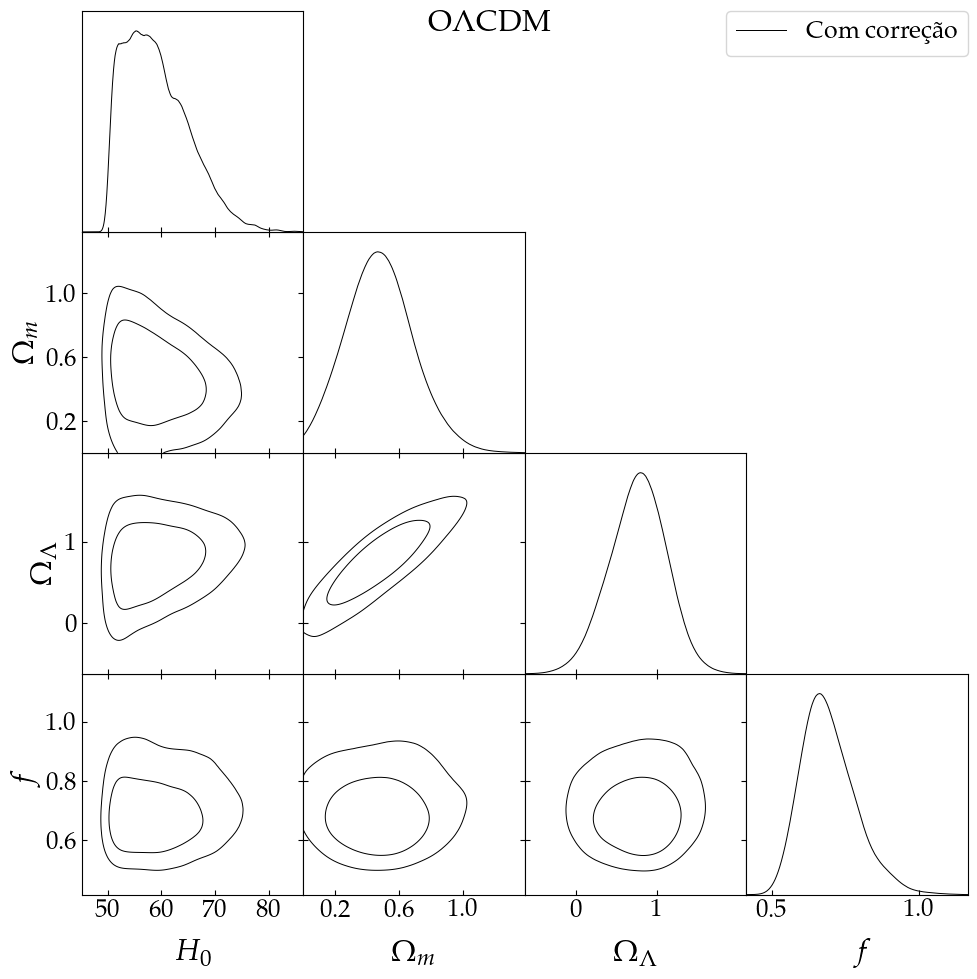

In [72]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF1], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
#g.export('fig/OLCDM-f.pdf')
plt.show()

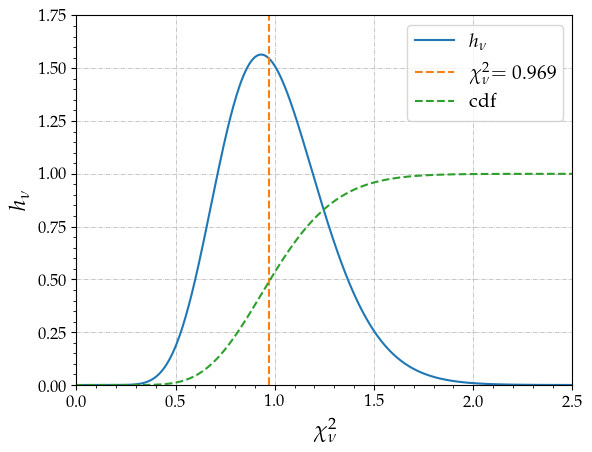

Probabilidade =  48.82313560445819
Chiv =  0.9694839880446714


In [73]:
chi2CF=chi2Hz(free_par([59.08927, 0.47946, 0.75942, 0.69360], freef=True, flat=False))
plotChiDist(chi2CF, len(par_HzCF))
chivCFperc, errF = quad(chiDist, 0, chi2CF/(ndata-len(par_HzCF)), args=(ndata-len(par_HzCF)))
print('Probabilidade = ', chivCFperc*100)
print('Chiv = ', chi2CF/(ndata-len(par_HzCF)))

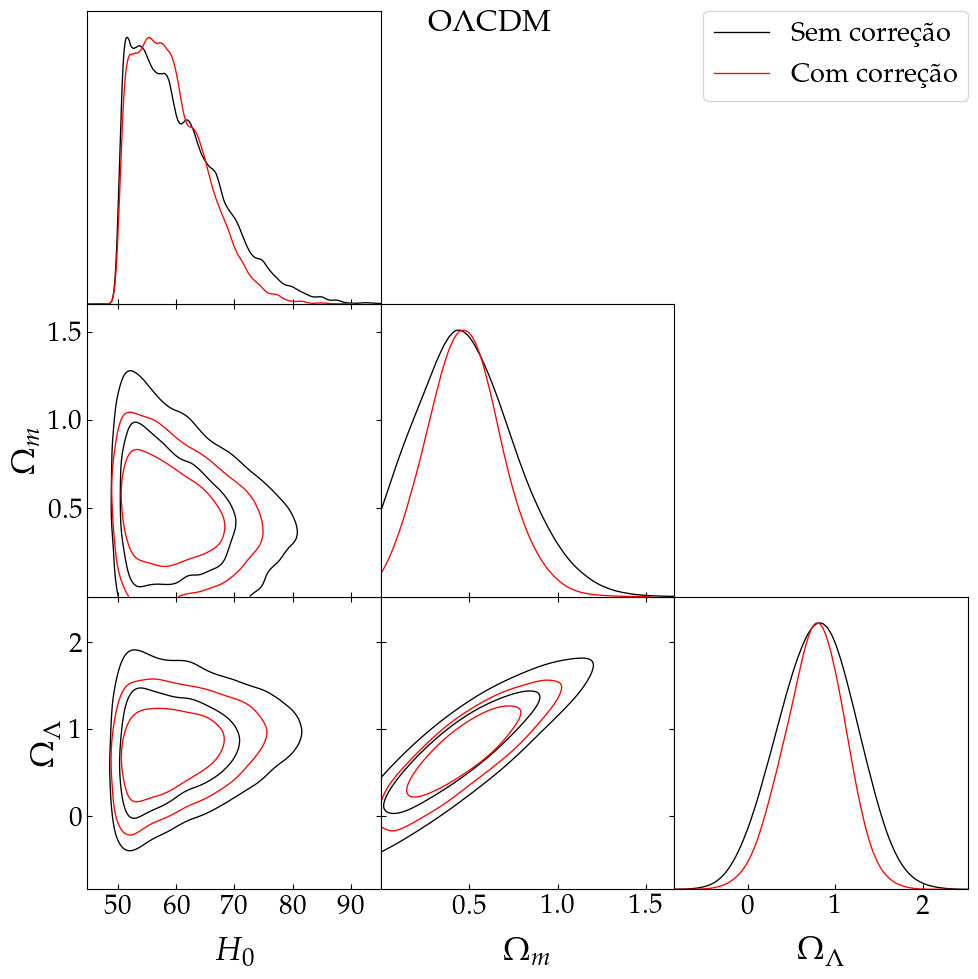

In [75]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC1, gsamplesHzCF1], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
plt.show()

### FLCDM sem correção

In [76]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True)
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  58.840379173281995
wm  =  0.38085847284234164
chi2min = 13.577361245927824
Total time: 0.008 seg


In [77]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:28<00:00, 172.59it/s]

Acceptance fraction: [0.6802 0.6924 0.683  0.6984 0.69   0.6878 0.6908 0.6894 0.6884 0.6982
 0.6912 0.69   0.684  0.695  0.6828 0.701  0.6982 0.6858 0.6946 0.6858
 0.6828 0.6842 0.6912 0.687  0.7016 0.7006 0.6848 0.699  0.7004 0.7
 0.6938 0.6892 0.6958 0.7074 0.6944 0.685  0.6926 0.6994 0.6978 0.682
 0.6878 0.695  0.6968 0.683  0.699  0.6954 0.6826 0.7068 0.703  0.6858
 0.6904 0.69   0.694  0.6966 0.681  0.7012 0.6924 0.6946 0.6794 0.6984
 0.684  0.6754 0.6976 0.6962 0.7006 0.688  0.6862 0.6878 0.7018 0.6918
 0.6888 0.6874 0.7002 0.6964 0.6984 0.7058 0.6898 0.6912 0.6824 0.6974
 0.6846 0.7058 0.7    0.7012 0.6978 0.686  0.6952 0.6838 0.694  0.6886
 0.6812 0.681  0.6912 0.6908 0.6958 0.679  0.7104 0.691  0.6906 0.6886]
Minimum acceptance: 0.6754
Maximum acceptance: 0.7104


In [78]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[35.86850265 35.51518136]
139.39806881210916
Convergiu! :)


In [79]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(28900, 2)


In [80]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 61.31821 +8.30301 +18.69099 -8.17870 -10.85732 (median: 60.01782, ml: 69.19300)
wm = 0.37385 +0.09492 +0.19865 -0.09438 -0.16248 (median: 0.36757, ml: 0.24809)


In [81]:
gsamplesHzF1 = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


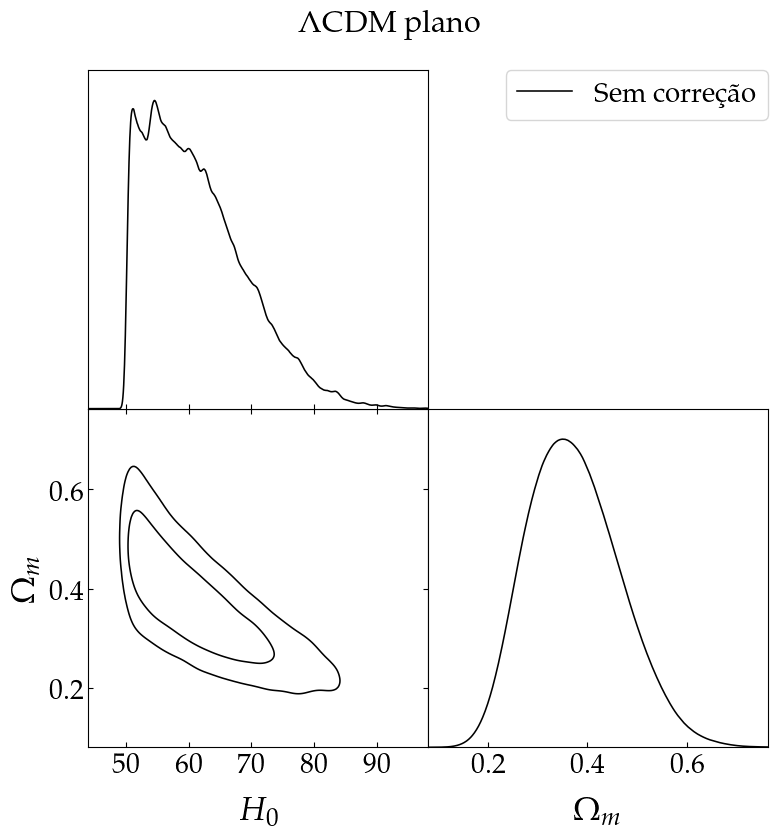

In [82]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF1], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
plt.show()
#g.export('fig/FLCDM-no-f.pdf')

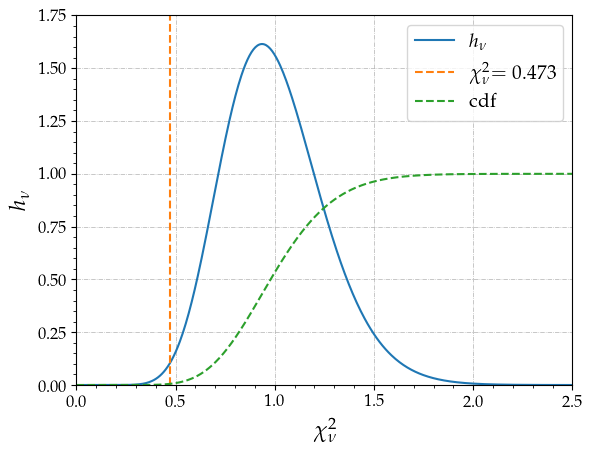

Probabilidade =  0.5619783650944856
Chiv =  0.47252957935403683


In [41]:
chi2F=chi2Hz(free_par([61.31821, 0.37385], freef=False, flat=True))
plotChiDist(chi2F, len(par_HzF))
chivFperc, errF = quad(chiDist, 0, chi2F/(ndata-len(par_HzF)), args=(ndata-len(par_HzF)))
print('Probabilidade = ', chivFperc*100)
print('Chiv = ', chi2F/(ndata-len(par_HzF)))

### FLCDM com correção

In [163]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True)
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  58.840385936119105
wm  =  0.38085840329888004
f  =  0.6414321378868799
chi2min = 3.692575589853874
Total time: 0.010 seg


In [164]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 166.22it/s]

Acceptance fraction: [0.6312 0.6296 0.6218 0.6284 0.6202 0.6124 0.6124 0.6274 0.6182 0.6388
 0.6148 0.6156 0.6182 0.6252 0.6136 0.6272 0.6222 0.6206 0.6252 0.6336
 0.6302 0.6354 0.6196 0.6306 0.6266 0.6358 0.6184 0.6326 0.6194 0.6438
 0.6202 0.6372 0.6294 0.6346 0.6288 0.6198 0.6282 0.627  0.6178 0.6182
 0.6194 0.6268 0.6326 0.6276 0.6196 0.6366 0.611  0.633  0.639  0.6078
 0.622  0.6236 0.6296 0.6156 0.6184 0.6216 0.6404 0.6204 0.6256 0.616
 0.6194 0.6272 0.6192 0.627  0.642  0.6326 0.6242 0.6136 0.625  0.6252
 0.6322 0.622  0.6108 0.6164 0.619  0.6234 0.635  0.6236 0.6238 0.6314
 0.6146 0.6456 0.6266 0.6162 0.6144 0.6244 0.6218 0.6144 0.6262 0.6222
 0.6188 0.619  0.6286 0.6292 0.6232 0.6244 0.639  0.6264 0.6208 0.6136]
Minimum acceptance: 0.6078
Maximum acceptance: 0.6456


In [165]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[43.59936192 43.37436184 41.96178112]
114.68057740559473
Convergiu! :)


In [166]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(24500, 3)


In [167]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 59.58065 +6.24316 +14.10638 -6.32779 -9.05478 (median: 58.81269, ml: 58.84039)
wm = 0.38420 +0.07424 +0.15280 -0.07336 -0.13345 (median: 0.38085, ml: 0.38086)
f = 0.68654 +0.08887 +0.21016 -0.08838 -0.15241 (median: 0.67733, ml: 0.64143)


In [168]:
gsamplesHzFf1 = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf1.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


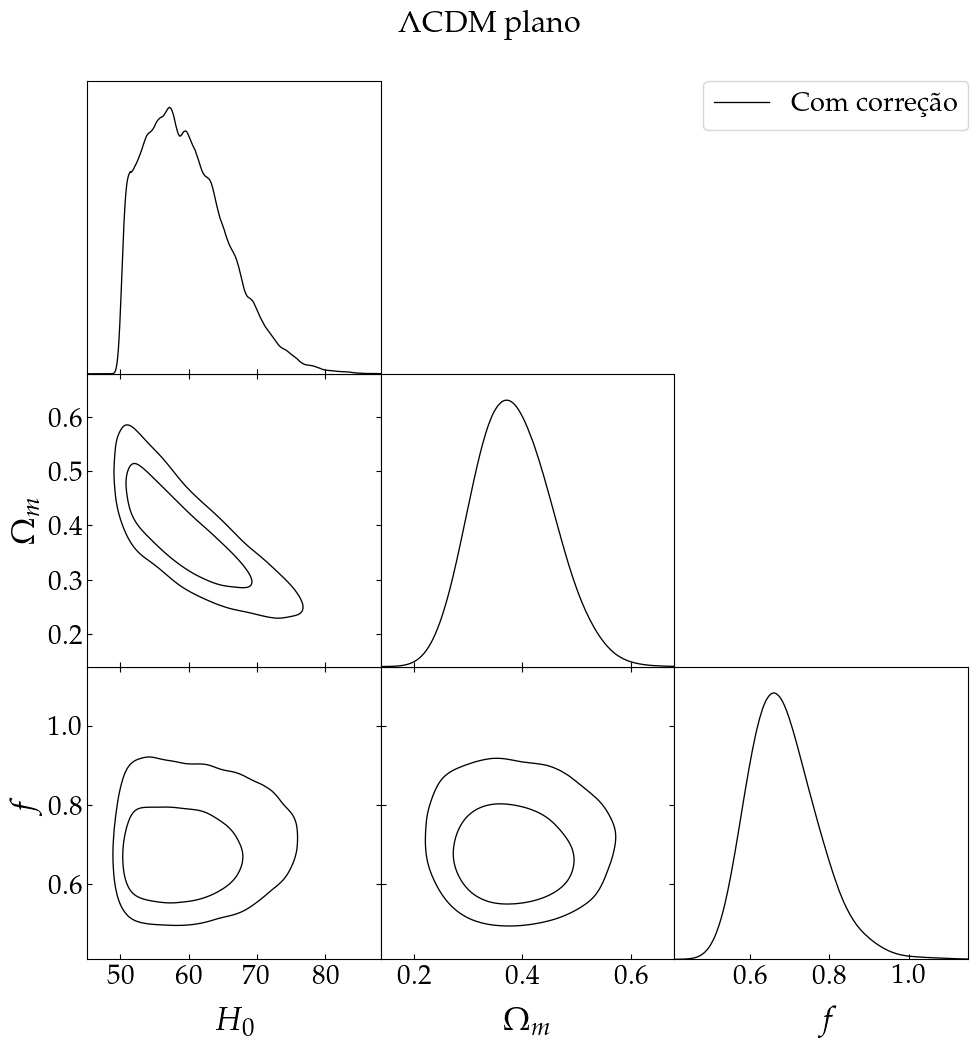

In [169]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf1], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
plt.show()
#g.export('fig/FLCDM-f.pdf')

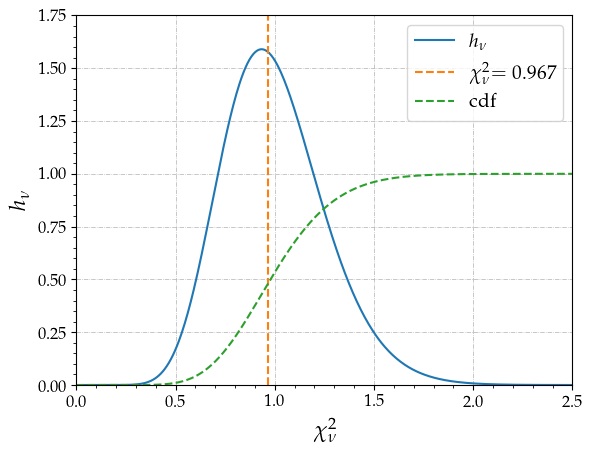

Probabilidade =  48.31553392089601
Chiv =  0.9671438971375252


In [105]:
chi2Ff=chi2Hz(free_par([59.61620, 0.38389, 0.68506], freef=True, flat=True))
plotChiDist(chi2Ff, len(par_HzFf))
chivFfperc, errF = quad(chiDist, 0, chi2Ff/(ndata-len(par_HzFf)), args=(ndata-len(par_HzFf)))
print('Probabilidade = ', chivFfperc*100)
print('Chiv = ', chi2Ff/(ndata-len(par_HzFf)))

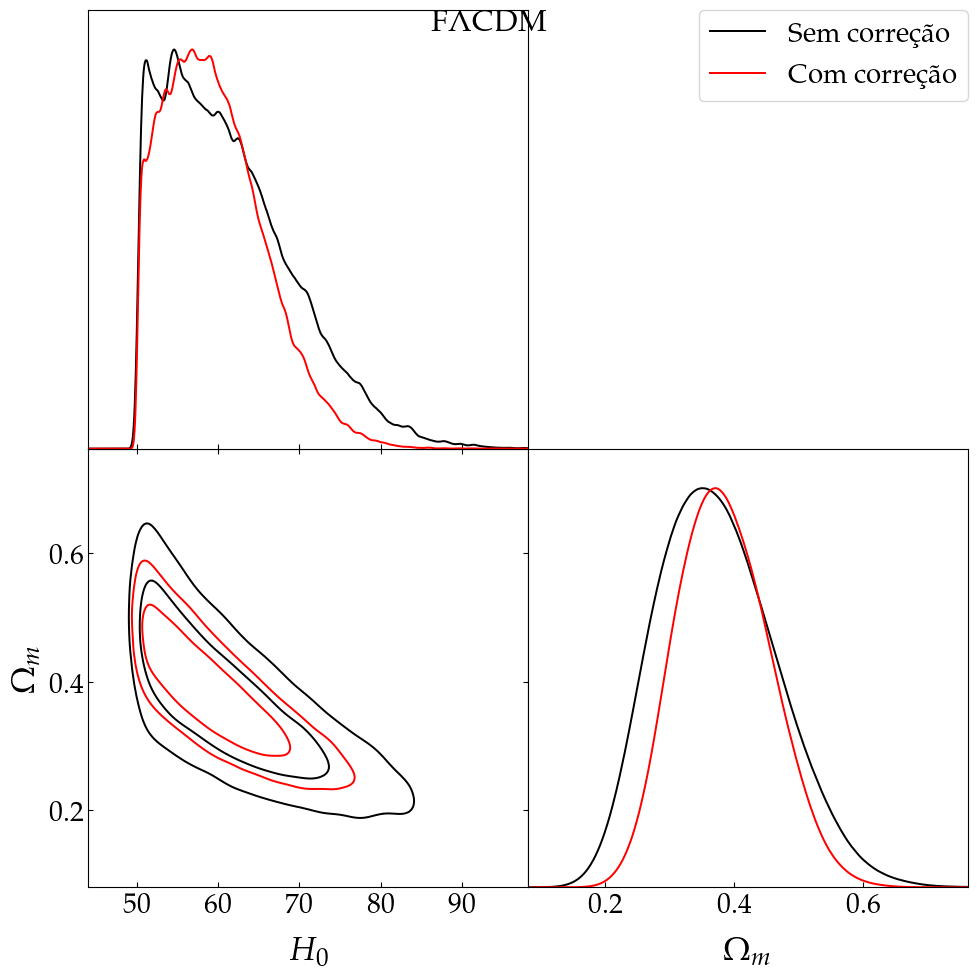

In [148]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF1, gsamplesHzFf1], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM", fontsize=22)
plt.show()

# Matriz de covariância: stat + imf + spsooo
### OLCDM sem correção

In [106]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
spsooo_intp = np.interp(zhzi, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_spsooo = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_spsooo[i,j] = hzi[i] * spsooo_intp[i] * hzi[j] * spsooo_intp[j]

cov_mat = cov_mat_imf + cov_mat_spsooo + cov_mat_diag
inv_cov = linalg.inv(cov_mat)

In [107]:
par_HzC = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndimC = len(par_HzC)
prefixC = 'LcdmHz32Cov'
parlabelsC = ["H_0","\\Omega_m", "\\Omega_\\Lambda"]
parlabtexC = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$"]
parnamesC = ['H0','wm','wl']

resultHzC = find_bestfit(lnprobHz, par_HzC, parnamesC, freef=False, flat=False)
par_HzC = resultHzC['x']

Maximum likelihood result:
H0  =  68.23979607209058
wm  =  0.36817483747777435
wl  =  0.7664466177568645
chi2min = 14.492332505458934
Total time: 0.009 seg


In [108]:
samplerHzC = run_emcee(par_HzC, 100, lnprobHz, False, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:28<00:00, 175.43it/s]

Acceptance fraction: [0.6326 0.6394 0.6222 0.6388 0.6318 0.6422 0.6276 0.6282 0.6352 0.6372
 0.6212 0.6342 0.621  0.6358 0.633  0.639  0.6408 0.6226 0.6266 0.6354
 0.6166 0.64   0.6308 0.6344 0.6336 0.6418 0.628  0.6306 0.6316 0.6298
 0.6282 0.6368 0.6424 0.6442 0.6288 0.6262 0.634  0.638  0.6332 0.6242
 0.6092 0.6328 0.6384 0.6364 0.6414 0.6438 0.619  0.6512 0.6552 0.6222
 0.625  0.6438 0.6384 0.631  0.6246 0.6392 0.6338 0.6222 0.6208 0.6324
 0.606  0.6202 0.6424 0.629  0.6392 0.6416 0.6214 0.6222 0.6258 0.6274
 0.628  0.6356 0.6306 0.6242 0.6362 0.6304 0.6488 0.6318 0.6288 0.634
 0.637  0.6342 0.6348 0.6402 0.6234 0.6404 0.6352 0.6234 0.6162 0.6168
 0.6268 0.6244 0.6392 0.642  0.629  0.6346 0.6216 0.6268 0.6354 0.6266]
Minimum acceptance: 0.606
Maximum acceptance: 0.6552


In [109]:
tauHzC = samplerHzC.get_autocorr_time()
print(tauHzC)

tauHzmaxC = np.amax(tauHzC)
r = nstepHz/tauHzmaxC
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[40.30325267 37.65117471 41.96002479]
119.16103541289336
Convergiu! :)


In [110]:
samplesHzC = burninthin(samplerHzC, 100)

(9600, 3)


In [111]:
MC_result(samplesHzC, par_HzC, parnamesC)

MCMC result:
H0 = 66.41331 +6.34130 +12.49787 -6.40469 -12.27978 (median: 66.35185, ml: 68.23980)
wm = 0.37361 +0.20192 +0.41276 -0.21082 -0.34259 (median: 0.36698, ml: 0.36817)
wl = 0.68478 +0.41788 +0.75832 -0.42352 -0.82352 (median: 0.69592, ml: 0.76645)


In [112]:
gsamplesHzC2 = MCSamples(samples=samplesHzC, names=parnamesC, labels=parlabelsC, ranges={'wm':(0, None)})
gsamplesHzC2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


In [119]:
MCResult(gsamplesHzC2)

H0 = 66.4133 + 6.3062 + 12.2256 -6.3631 -11.9826
wm = 0.3736 + 0.1827 + 0.3389 -0.2298 -0.3736
wl = 0.6848 + 0.4371 + 0.7434 -0.3891 -0.8079


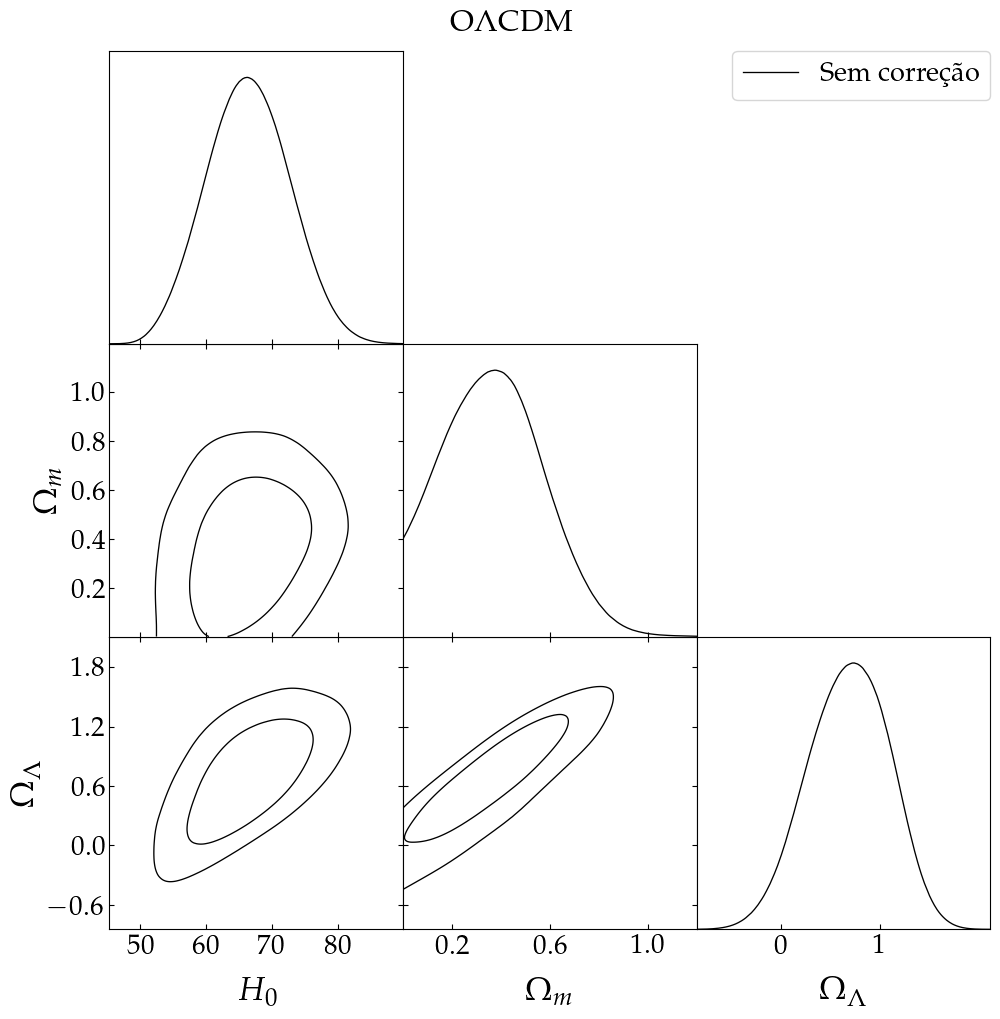

In [120]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC2], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)
plt.show()
#g.export('fig/OLCDM-no-f.pdf')

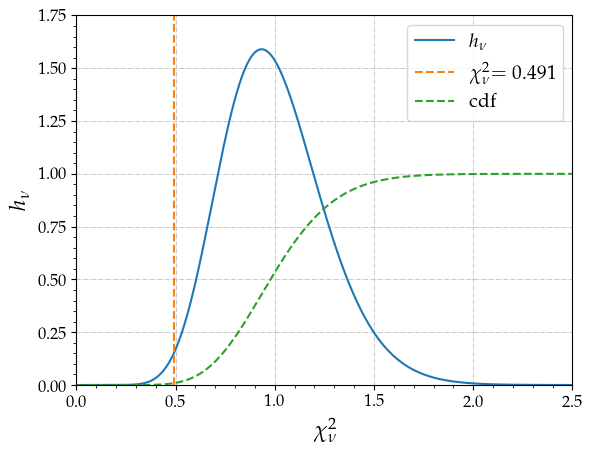

Probabilidade =  0.8797960537483572
Chiv =  0.4908446425047633


In [121]:
chi2mC = chi2Hz(free_par([66.4133, 0.3736, 0.6848], freef=False, flat=False))
chivCperc, errF = quad(chiDist, 0, chi2mC/(ndata-len(par_HzC)), args=(ndata-len(par_HzC)))
plotChiDist(chi2mC, len(par_HzC))
print('Probabilidade = ', chivCperc*100)
print('Chiv = ', chi2mC/(ndata-len(par_HzC)))

### OLCDM com correção

In [122]:
par_HzCF = [69.1929957609451,0.2480895086492853, 0.6862431649000225, .9]
ndimCF = len(par_HzCF)
prefixCF = 'OLcdmHz32Cov'
parlabelsCF = ["H_0","\\Omega_m", "\\Omega_\\Lambda", "f"]
parlabtexCF = ["$H_0$","$\\Omega_m$", "$\\Omega_\\Lambda$", "$f$"]
parnamesCF = ['H0','wm','wl', 'f']

resultHzCF = find_bestfit(lnprobHz, par_HzCF, parnamesCF, freef=True, flat=False)
par_HzCF = resultHzCF['x']

Maximum likelihood result:
H0  =  68.23979760010327
wm  =  0.36817486786682574
wl  =  0.7664467235563078
f  =  0.6626926796390887
chi2min = 5.844701127305733
Total time: 0.010 seg


In [123]:
samplerHzCF = run_emcee(par_HzCF, 100, lnprobHz, True, False, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 161.29it/s]

Acceptance fraction: [0.5888 0.5996 0.5816 0.5894 0.5868 0.5698 0.5816 0.5788 0.5842 0.59
 0.5812 0.5786 0.5728 0.5652 0.5852 0.5956 0.5926 0.583  0.5816 0.588
 0.5854 0.6028 0.5892 0.5892 0.5764 0.5994 0.5796 0.587  0.5814 0.5948
 0.5802 0.5846 0.592  0.5976 0.587  0.5714 0.5836 0.5838 0.5834 0.5924
 0.5716 0.5834 0.5888 0.5842 0.5798 0.5982 0.576  0.588  0.5914 0.5934
 0.587  0.601  0.5746 0.5908 0.5846 0.594  0.5852 0.5748 0.579  0.592
 0.5696 0.5794 0.5896 0.5842 0.5808 0.5854 0.5916 0.576  0.5908 0.5852
 0.5924 0.5742 0.5856 0.5722 0.5882 0.5894 0.5856 0.5744 0.573  0.5858
 0.5922 0.5878 0.598  0.5806 0.5888 0.58   0.5854 0.57   0.586  0.5854
 0.5844 0.584  0.5928 0.596  0.5962 0.5888 0.5874 0.5824 0.5794 0.587 ]
Minimum acceptance: 0.5652
Maximum acceptance: 0.6028


In [124]:
tauHzCF = samplerHzCF.get_autocorr_time()
print(tauHzCF)

tauHzmaxCF = np.amax(tauHzCF)
r = nstepHz/tauHzmaxCF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[45.59272248 43.03268755 43.80132429 45.81077343]
109.14463183047556
Convergiu! :)


In [125]:
samplesHzCF = burninthin(samplerHzCF, 100)

(9600, 4)


In [126]:
MC_result(samplesHzCF, par_HzCF, parnamesCF)

MCMC result:
H0 = 67.05344 +4.63936 +9.36445 -4.68407 -9.68808 (median: 67.12285, ml: 68.23980)
wm = 0.35637 +0.15917 +0.32090 -0.16304 -0.30570 (median: 0.35489, ml: 0.36817)
wl = 0.69514 +0.32179 +0.58724 -0.32563 -0.67693 (median: 0.71465, ml: 0.76645)
f = 0.72603 +0.09663 +0.23145 -0.09600 -0.16874 (median: 0.71596, ml: 0.66269)


In [127]:
gsamplesHzCF2 = MCSamples(samples=samplesHzCF, names=parnamesCF, labels=parlabelsCF, ranges={'wm':(0, None)})
gsamplesHzCF2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


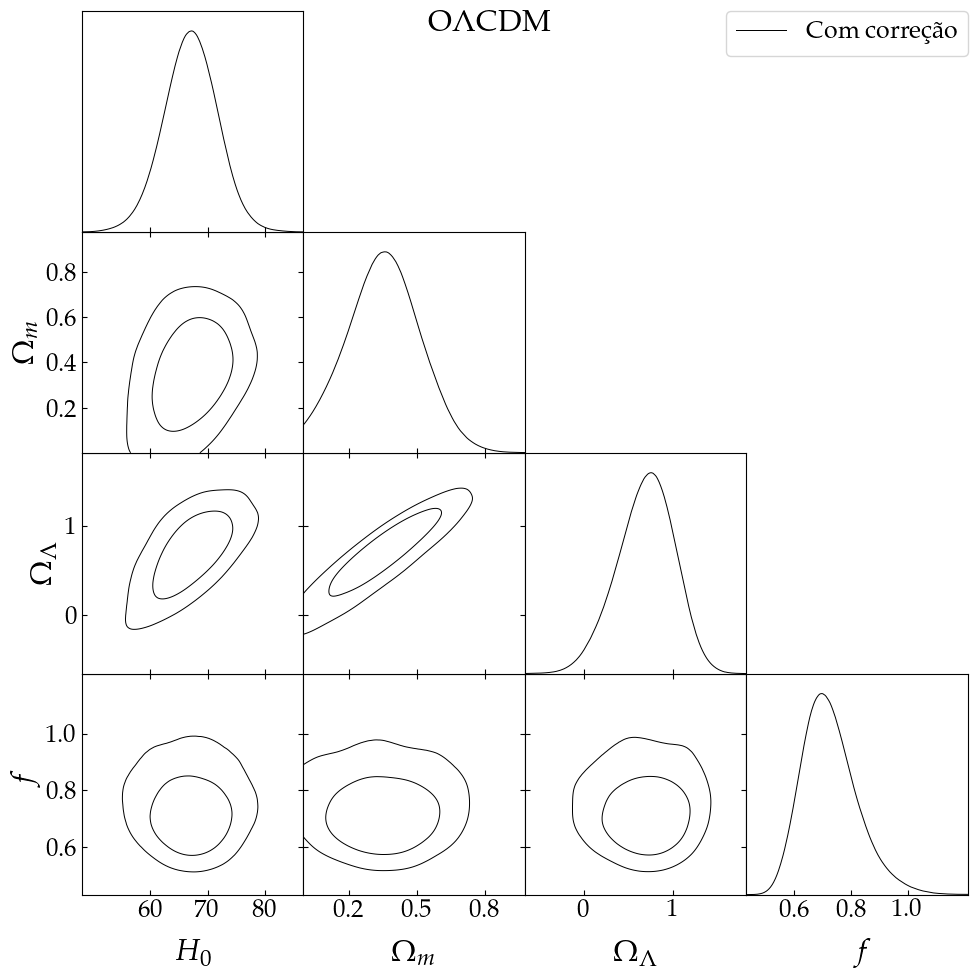

In [128]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF2], filled=False, legend_labels=['Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
#g.export('fig/OLCDM-f.pdf')
plt.show()

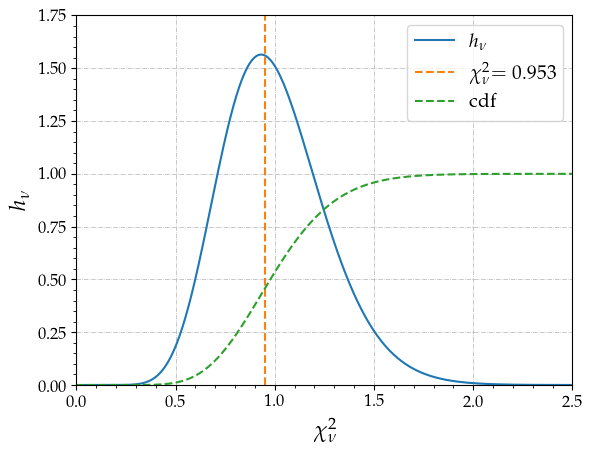

Probabilidade =  46.25119098465147
Chiv =  0.9529294908142621


In [129]:
chi2CF=chi2Hz(free_par([67.05344, 0.35637, 0.69514, 0.72603], freef=True, flat=False))
plotChiDist(chi2CF, len(par_HzCF))
chivCFperc, errF = quad(chiDist, 0, chi2CF/(ndata-len(par_HzCF)), args=(ndata-len(par_HzCF)))
print('Probabilidade = ', chivCFperc*100)
print('Chiv = ', chi2CF/(ndata-len(par_HzCF)))

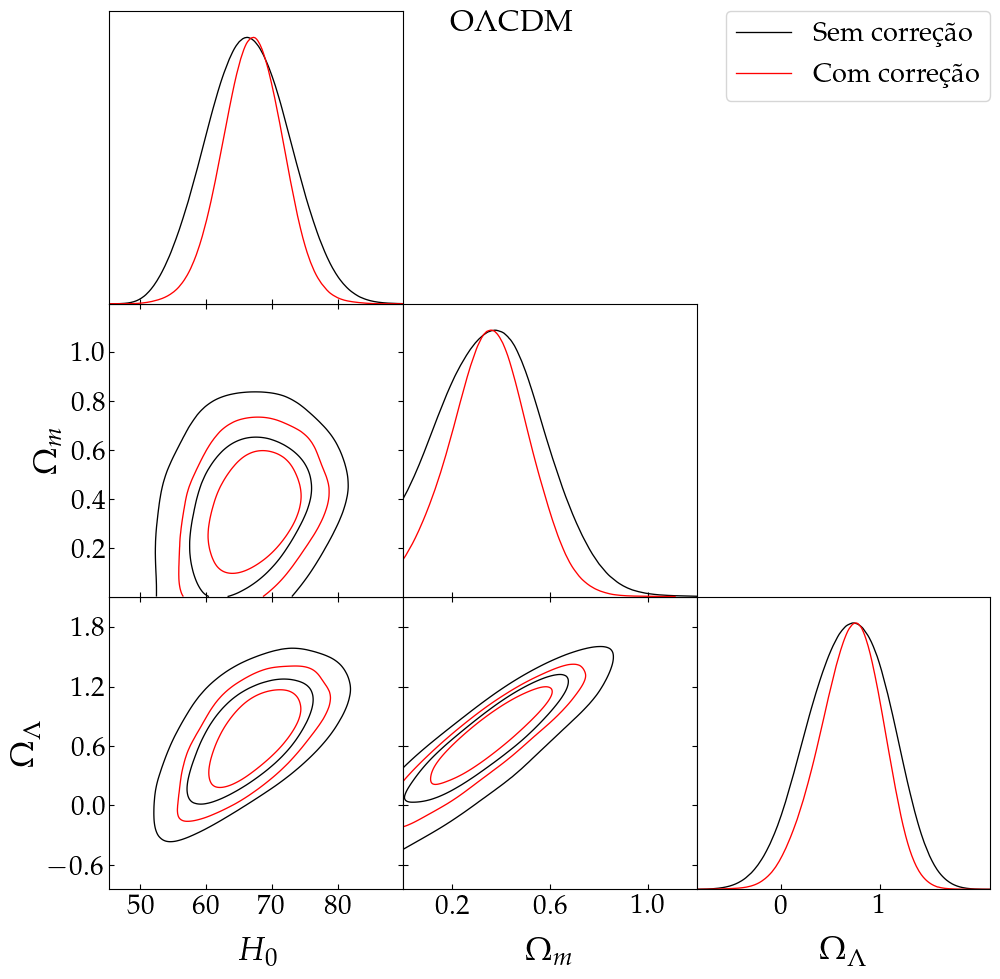

In [130]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC2, gsamplesHzCF2], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
plt.show()

### FLCDM sem correção

In [131]:
par_HzF = [69.1929957609451, 0.2480895086492853]
ndimF = len(par_HzF)
prefixF = 'FlatLcdmHz32Cov'
parlabelsF = ["H_0","\\Omega_m"]
parlabtexF = ["$H_0$","$\\Omega_m$"]
parnamesF = ['H0','wm']

resultHzF = find_bestfit(lnprobHz, par_HzF, parnamesF, freef=False, flat=True)
par_mlHzF = resultHzF['x']

Maximum likelihood result:
H0  =  67.53068384148416
wm  =  0.32398578404277734
chi2min = 14.533396574606178
Total time: 0.008 seg


In [132]:
samplerHzF = run_emcee(par_HzF, 100, lnprobHz, False, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:29<00:00, 169.21it/s]

Acceptance fraction: [0.7178 0.7188 0.7028 0.7176 0.7068 0.7158 0.7028 0.7122 0.7142 0.7162
 0.7096 0.7132 0.7066 0.7122 0.706  0.7242 0.7278 0.7034 0.709  0.704
 0.711  0.7152 0.707  0.7024 0.7216 0.7226 0.7126 0.7162 0.707  0.7182
 0.7182 0.7108 0.7122 0.722  0.7102 0.7114 0.723  0.7216 0.7116 0.7108
 0.6978 0.7132 0.71   0.7086 0.7116 0.7254 0.7024 0.7308 0.7274 0.7156
 0.7122 0.7136 0.7118 0.7156 0.7126 0.7122 0.7138 0.7092 0.6946 0.7136
 0.71   0.7086 0.7124 0.7148 0.7194 0.7164 0.7178 0.6998 0.7202 0.7178
 0.7162 0.713  0.7128 0.713  0.7096 0.7146 0.7226 0.7214 0.7202 0.7136
 0.7072 0.7128 0.7128 0.7108 0.711  0.7224 0.6982 0.7108 0.719  0.7098
 0.7108 0.7122 0.7094 0.7202 0.715  0.7066 0.7222 0.7204 0.7096 0.702 ]
Minimum acceptance: 0.6946
Maximum acceptance: 0.7308


In [133]:
tauHzF = samplerHzF.get_autocorr_time()
print(tauHzF)

tauHzmaxF = np.amax(tauHzF)
r = nstepHz/tauHzmaxF
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[31.57956999 32.96579315]
151.67237073317526
Convergiu! :)


In [134]:
samplesHzF = burninthin(samplerHzF, tauHzF)

(32900, 2)


In [135]:
MC_result(samplesHzF, par_HzF, parnamesF)

MCMC result:
H0 = 66.57164 +5.44725 +10.79669 -5.47447 -10.84218 (median: 66.57591, ml: 69.19300)
wm = 0.34412 +0.07113 +0.17260 -0.07128 -0.12266 (median: 0.33559, ml: 0.24809)


In [136]:
gsamplesHzF2 = MCSamples(samples=samplesHzF, names=parnamesF, labels=parlabelsF, ranges={'wm':(0, None)})
gsamplesHzF2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


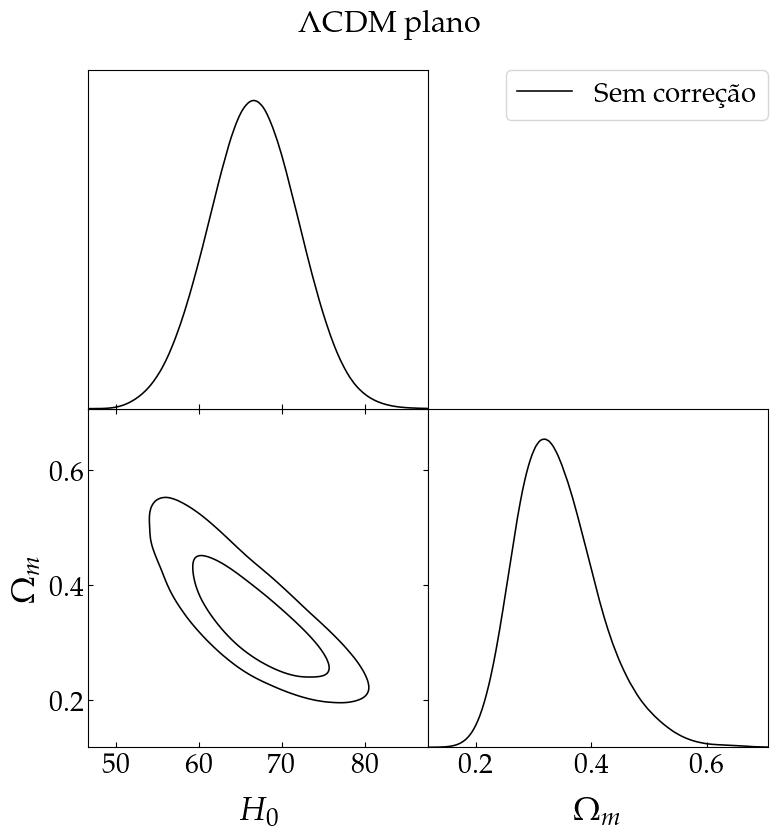

In [137]:
g = plots.getSubplotPlotter(width_inch=8)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF2], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
plt.show()
#g.export('fig/FLCDM-no-f.pdf')

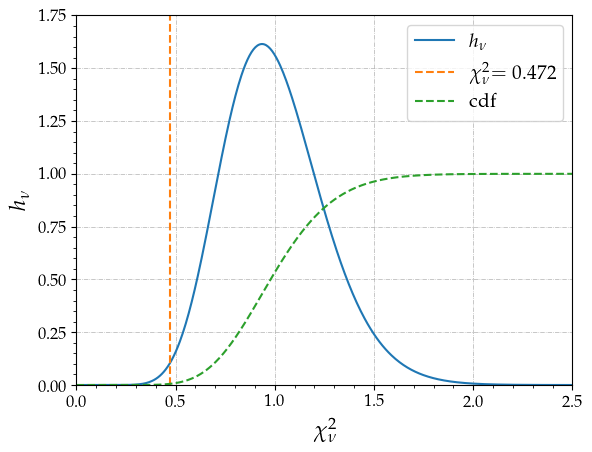

Probabilidade =  0.5553912423929911
Chiv =  0.4719028215044148


In [138]:
chi2F=chi2Hz(free_par([66.57164, 0.34412], freef=False, flat=True))
plotChiDist(chi2F, len(par_HzF))
chivFperc, errF = quad(chiDist, 0, chi2F/(ndata-len(par_HzF)), args=(ndata-len(par_HzF)))
print('Probabilidade = ', chivFperc*100)
print('Chiv = ', chi2F/(ndata-len(par_HzF)))

### FLCDM com correção

In [139]:
par_HzFf = [69.1929957609451,0.2480895086492853, .9]
ndimFf = len(par_HzFf)
prefixFf = 'LcdmHz32CovCorr'
parlabelsFf = ['H_0','\\Omega_m', 'f']
parlabtexFf = ['$H_0$','$\\Omega_m$', '$f$']
parnamesFf = ['H0','wm', 'f']

resultHzFf = find_bestfit(lnprobHz, par_HzFf, parnamesFf, freef=True, flat=True)
par_mlHzFf = resultHzFf['x']

Maximum likelihood result:
H0  =  67.53067072166489
wm  =  0.32398590831550955
f  =  0.6636308715882958
chi2min = 5.938074505277914
Total time: 0.007 seg


In [141]:
samplerHzFf = run_emcee(par_HzFf, 100, lnprobHz, True, True, 2.0, nstepHz)

100%|██████████████████████████████████████| 5000/5000 [00:30<00:00, 161.85it/s]

Acceptance fraction: [0.653  0.6534 0.6338 0.6492 0.6346 0.6216 0.6382 0.645  0.6494 0.6496
 0.6294 0.6436 0.6378 0.643  0.6424 0.6538 0.6502 0.643  0.6436 0.647
 0.6394 0.6606 0.6432 0.632  0.6404 0.65   0.635  0.6398 0.6398 0.6502
 0.6422 0.6476 0.6516 0.6566 0.6404 0.6376 0.6474 0.6346 0.6354 0.6406
 0.6208 0.6434 0.6386 0.6328 0.6408 0.6518 0.6376 0.6496 0.656  0.6446
 0.6472 0.6464 0.6378 0.6338 0.6532 0.6482 0.6372 0.6358 0.6426 0.6598
 0.628  0.637  0.6436 0.6448 0.644  0.6438 0.6382 0.6368 0.634  0.649
 0.6462 0.6406 0.6394 0.6288 0.639  0.6408 0.633  0.6282 0.6388 0.6486
 0.6416 0.652  0.637  0.6416 0.6382 0.6458 0.6436 0.6358 0.6378 0.632
 0.639  0.65   0.6416 0.6466 0.662  0.6374 0.6512 0.6382 0.6474 0.6388]
Minimum acceptance: 0.6208
Maximum acceptance: 0.662


In [142]:
tauHzFf = samplerHzFf.get_autocorr_time()
print(tauHzFf)

tauHzmaxFf = np.amax(tauHzFf)
r = nstepHz/tauHzmaxFf
print(r)

if(r>50):
    print('Convergiu! :)')
else:
    print('Não convergiu... :\'(:' )

[38.19927892 39.22406749 38.02355691]
127.47275638185381
Convergiu! :)


In [143]:
samplesHzFf = burninthin(samplerHzFf, tauHzFf)

(25900, 3)


In [144]:
MC_result(samplesHzFf, par_mlHzFf, parnamesFf)

MCMC result:
H0 = 67.07174 +3.85154 +7.83154 -3.87731 -8.07663 (median: 67.15453, ml: 67.53067)
wm = 0.33317 +0.04869 +0.11668 -0.04877 -0.08884 (median: 0.32881, ml: 0.32399)
f = 0.71553 +0.09416 +0.22479 -0.09273 -0.16130 (median: 0.70445, ml: 0.66363)


In [145]:
gsamplesHzFf2 = MCSamples(samples=samplesHzFf, names=parnamesFf, labels=parlabelsFf, ranges={'wm':(0, None)})
gsamplesHzFf2.updateSettings({'countours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


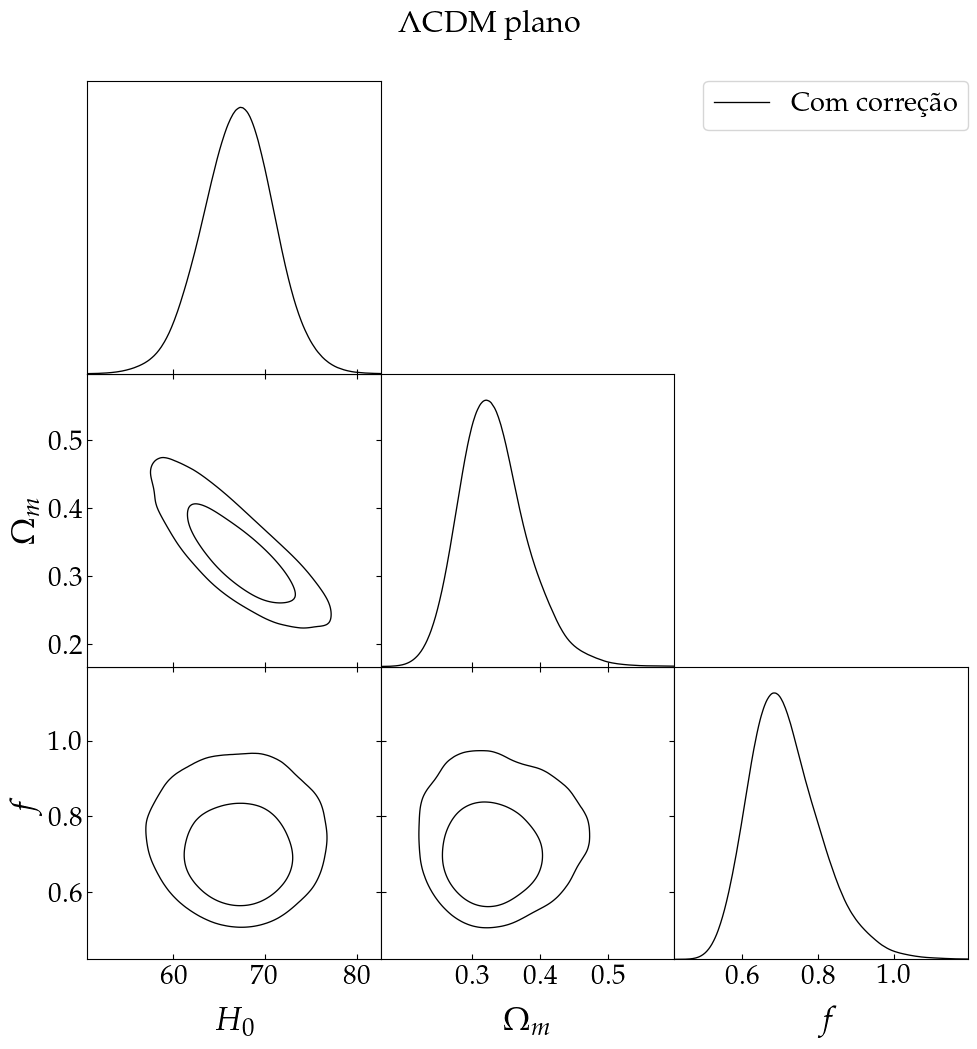

In [146]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf2], filled=False, legend_labels=['Com correção'])
g.fig.suptitle(r"$\Lambda$CDM plano", fontsize=22, y=1.05)
plt.show()
#g.export('fig/FLCDM-f.pdf')

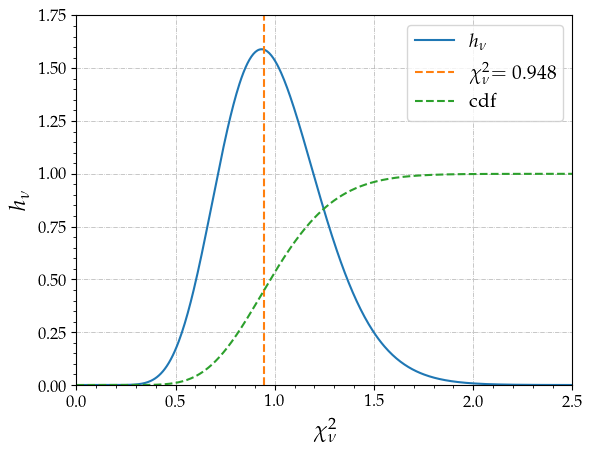

Probabilidade =  45.21098126680719
Chiv =  0.9475225807571249


In [147]:
chi2Ff=chi2Hz(free_par([67.07174, 0.33317, 0.71553], freef=True, flat=True))
plotChiDist(chi2Ff, len(par_HzFf))
chivFfperc, errF = quad(chiDist, 0, chi2Ff/(ndata-len(par_HzFf)), args=(ndata-len(par_HzFf)))
print('Probabilidade = ', chivFfperc*100)
print('Chiv = ', chi2Ff/(ndata-len(par_HzFf)))

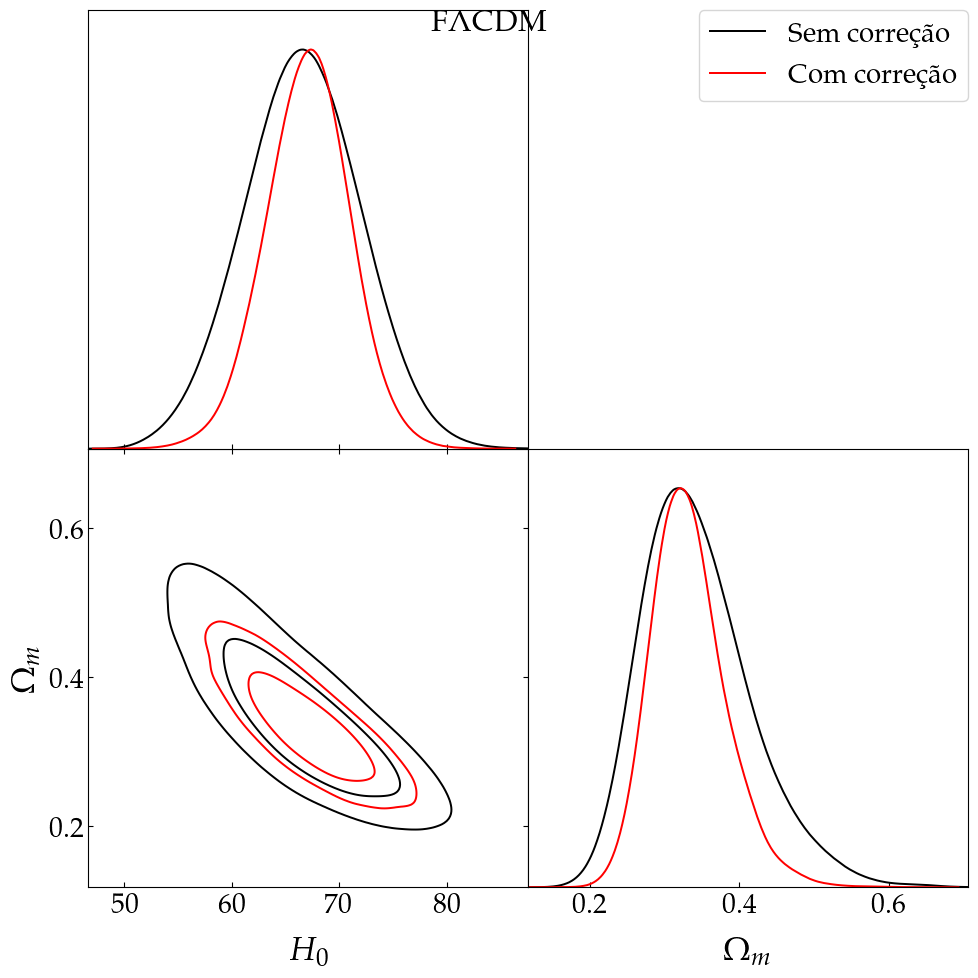

In [149]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF2, gsamplesHzFf2], filled=False, legend_labels=['Sem correção', 'Com correção'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM", fontsize=22)
plt.show()

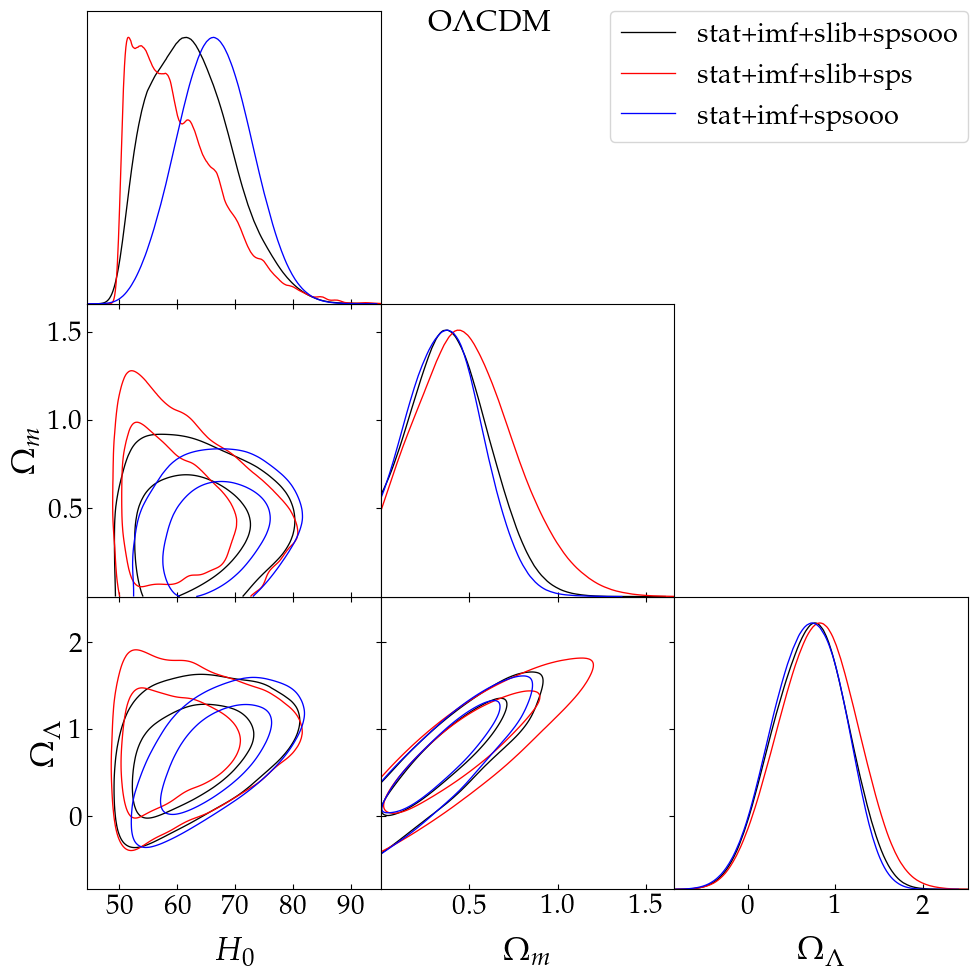

In [151]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzC, gsamplesHzC1, gsamplesHzC2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22)
plt.show()

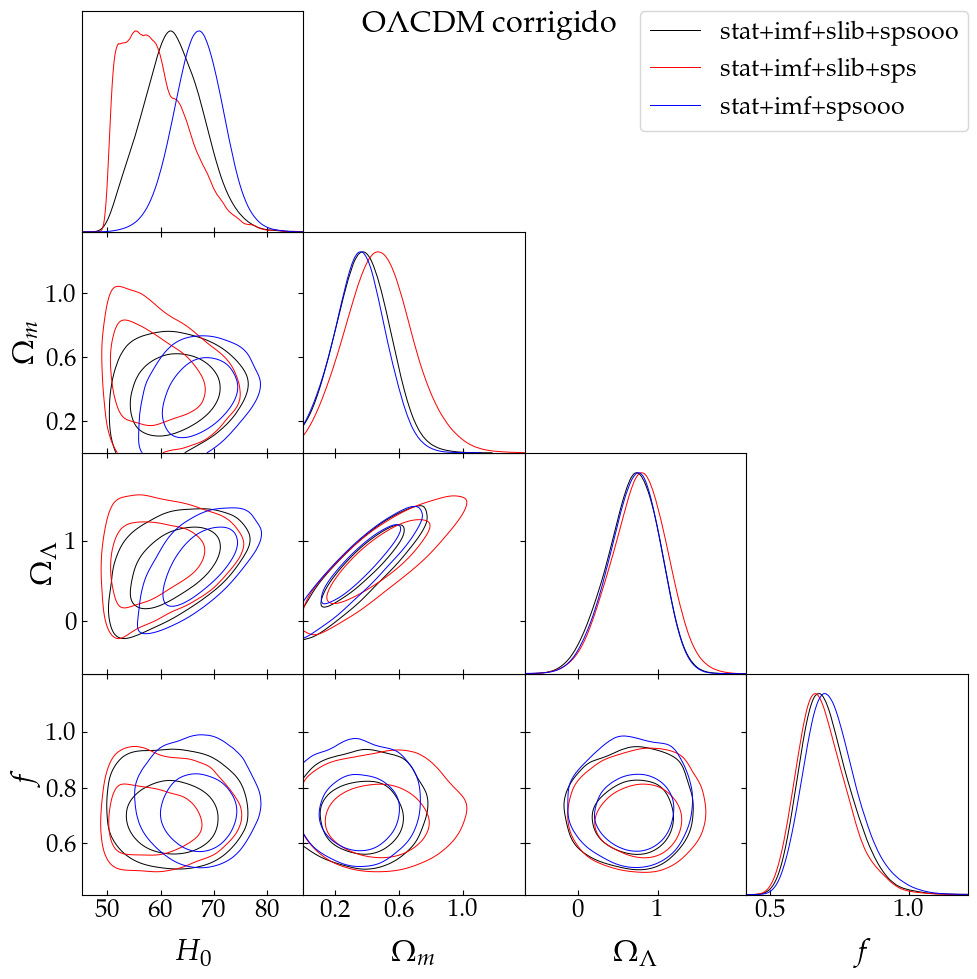

In [152]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzCF, gsamplesHzCF1, gsamplesHzCF2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"O$\Lambda$CDM corrigido", fontsize=22)
plt.show()

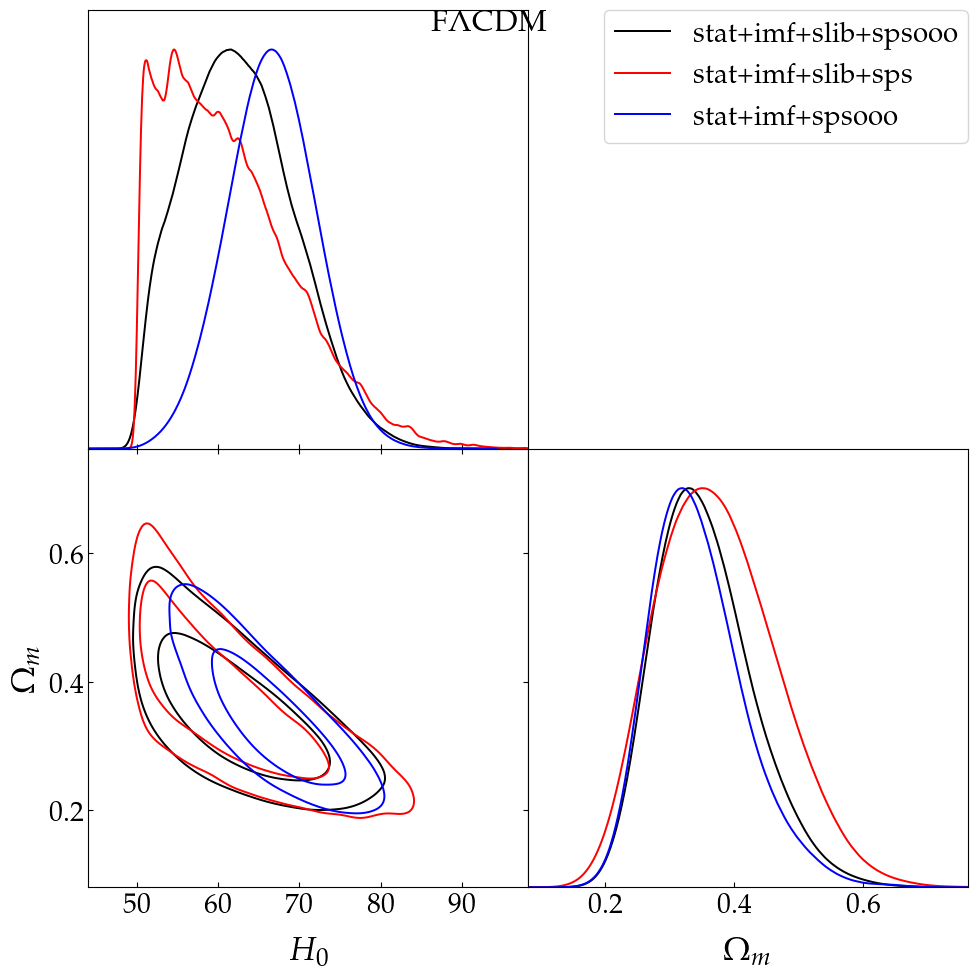

In [154]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzF, gsamplesHzF1, gsamplesHzF2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM", fontsize=22)
plt.show()

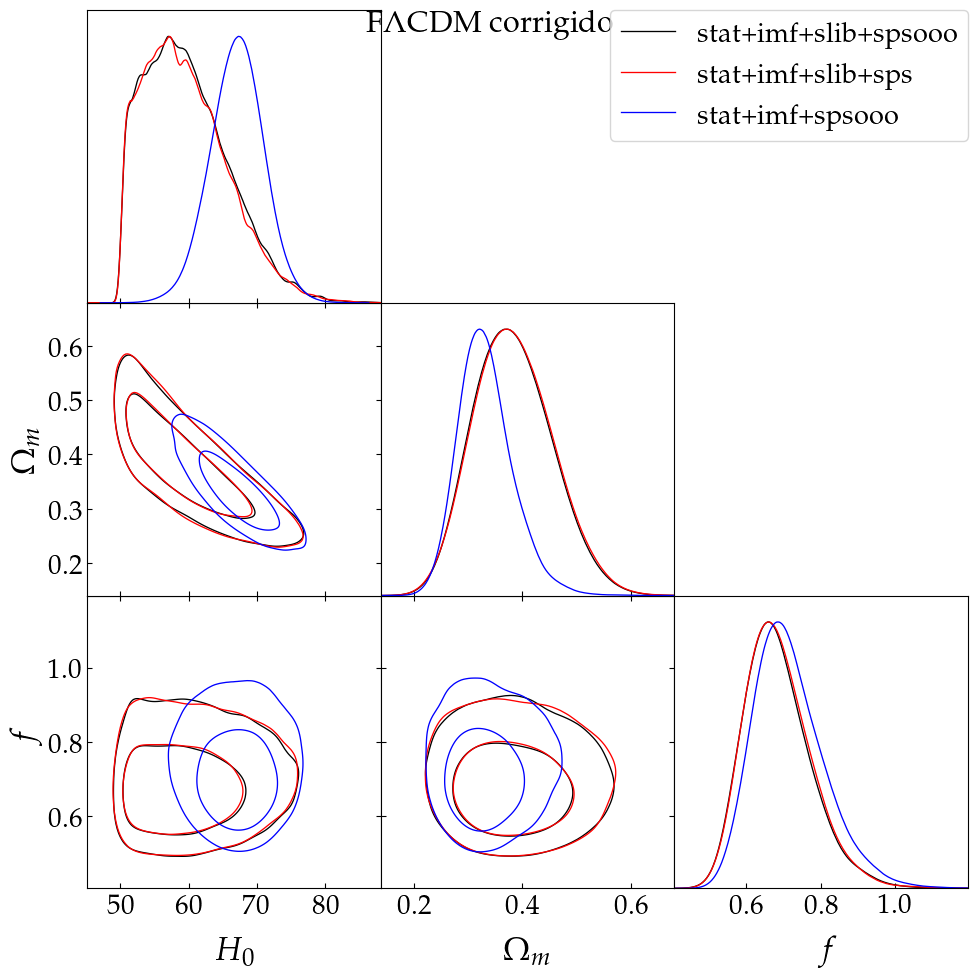

In [170]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamplesHzFf, gsamplesHzFf1, gsamplesHzFf2], filled=False, legend_labels=['stat+imf+slib+spsooo', 'stat+imf+slib+sps', 'stat+imf+spsooo'], legend_loc='upper right')
g.fig.suptitle(r"F$\Lambda$CDM corrigido", fontsize=22)
plt.show()